# 3. Event-Driven Market Reaction (Improved)

**Research context:** Building on EDA and Hypothesis Testing results:
- Raw correlation (r ≈ 0.49) between paper counts and ETF price is **spurious**.
- After stationarising, linear relationship collapses to r ≈ −0.02.
- A weak 3-day Granger precedence exists (p < 0.05) but explains < 0.2% of variance.

This notebook asks: **do individual landmark AI publications trigger measurable abnormal reactions in BOTZ trading volume or returns around the event date?**

### Analytical pipeline
```
Data & Events → Volume Analysis (SCAV) → Return Analysis (CAR) → Multi-Window Robustness
→ Average Event-Time Plot → Significance Testing (BH-FDR) → Final Hypothesis Decision
```

> **Methodological note:** Event studies measure *market attention* (volume) and *price impact* (returns) separately. A paper might spike trading activity without moving the price — or vice versa. Analysing both dimensions gives a fuller picture.

### Improvements over previous version
| Issue | Fix |
|-------|-----|
| AlphaFold 3 date outside dataset range | Removed; note added |
| Event window only [-1, +1] | Multi-window robustness check added |
| Volume-only analysis | CAR (Cumulative Abnormal Returns) added |
| No average event-time plot | Canonical event-time aggregation added |
| Event contamination unaddressed | Minimum 60-day inter-event spacing filter |
| Wilcoxon p/2 workaround | `alternative='greater'` used directly |
| Colour palette inconsistent with other notebooks | Unified palette applied |


## 0. Setup & Configuration

In [42]:
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Colour palette (consistent with 01_EDA and 02_HT) ────────────────────────
C_ETF    = '#1f77b4'   # steel blue  → price / returns
C_PAPER  = '#ff7f0e'   # orange      → paper counts
C_TREND  = '#d62728'   # red         → event date / regression
C_ACCENT = '#2ca02c'   # green       → positive / significant
C_NEUTRAL = '#7f7f7f'  # gray        → insignificant / baseline

# ── Shared constants ──────────────────────────────────────────────────────────
ESTIMATION_LOOKBACK   = 120    # trading days for baseline
ESTIMATION_GAP        = 10     # trading days buffer before event
EVENT_WINDOWS         = [(-1, 1), (-3, 3), (-5, 10)]   # robustness set
PRIMARY_WINDOW        = (-1, 1)
MIN_EVENT_SPACING     = 60     # min trading days between events (contamination filter)
ALPHA                 = 0.05
TICKERS               = ['BOTZ', 'QQQ']
BENCHMARK             = 'QQQ'

print('Setup complete.')


Setup complete.


## 1. Data & Event Set

### Event selection rationale
Events are chosen as widely-cited, milestone arXiv publications that attracted mainstream media attention. Two filters are applied before analysis:

1. **Date range filter** — events must fall within available trading data (post-2016).
2. **Minimum spacing filter** — if two events are within `MIN_EVENT_SPACING` trading days of each other, the second is flagged as potentially contaminated (its baseline estimation window may overlap the first event's window).

> **Removed from original list:** AlphaFold 3 (2024-05-08) — outside the BOTZ dataset range. Results using post-2023 data would require a separate data pull and are out of scope here.


In [43]:
PAPER_EVENTS = [
    {'name': 'Grad-CAM',                          'date': '2016-10-07'},
    {'name': 'GCN',                               'date': '2017-03-26'},
    {'name': 'Transformer (Attention Is All You Need)', 'date': '2017-06-12'},
    {'name': 'BERT',                              'date': '2018-10-11'},
    {'name': 'EfficientNet',                      'date': '2019-05-28'},
    {'name': 'GPT-3',                             'date': '2020-05-28'},
    {'name': 'ViT',                               'date': '2020-10-22'},
    {'name': 'CLIP',                              'date': '2021-02-26'},
    {'name': 'LoRA',                              'date': '2021-06-17'},
    {'name': 'AlphaFold 2',                       'date': '2021-07-15'},
    {'name': 'GPT-4 Technical Report',            'date': '2023-03-15'},
    # AlphaFold 3 (2024-05-08) removed — outside dataset range
]

print(f'Events defined: {len(PAPER_EVENTS)}')
for e in PAPER_EVENTS:
    print(f"  {e['date']}  {e['name']}")


Events defined: 11
  2016-10-07  Grad-CAM
  2017-03-26  GCN
  2017-06-12  Transformer (Attention Is All You Need)
  2018-10-11  BERT
  2019-05-28  EfficientNet
  2020-05-28  GPT-3
  2020-10-22  ViT
  2021-02-26  CLIP
  2021-06-17  LoRA
  2021-07-15  AlphaFold 2
  2023-03-15  GPT-4 Technical Report


## 2. Data Download & Helper Functions

In [44]:
# ── Download helpers ──────────────────────────────────────────────────────────
def download_market_data(start_date: str, end_date: str) -> pd.DataFrame:
    """Download OHLCV for BOTZ and QQQ; return aligned DataFrame."""
    raw = yf.download(TICKERS, start=start_date, end=end_date,
                      progress=False, auto_adjust=False)
    if raw.empty:
        raise ValueError('yfinance returned empty data.')
    
    # Flatten MultiIndex columns: (field, ticker) → field_ticker
    close  = raw['Close'].rename(columns={'BOTZ': 'botz_close',  'QQQ': 'qqq_close'})
    volume = raw['Volume'].rename(columns={'BOTZ': 'botz_volume', 'QQQ': 'qqq_volume'})
    
    df = pd.concat([close, volume], axis=1).dropna()
    df['botz_return'] = df['botz_close'].pct_change()
    df['qqq_return']  = df['qqq_close'].pct_change()
    df['vol_ratio']   = df['botz_volume'] / df['qqq_volume'].replace(0, np.nan)
    df['excess_return'] = df['botz_return'] - df['qqq_return']  # market-adjusted return
    df.dropna(inplace=True)
    return df


def first_trading_day_on_or_after(index: pd.DatetimeIndex,
                                   event_date: pd.Timestamp) -> pd.Timestamp | None:
    """Return the first index date >= event_date, or None if out of range."""
    valid = index[index >= event_date]
    return valid[0] if len(valid) > 0 else None


# ── Download data ─────────────────────────────────────────────────────────────
all_dates = [pd.to_datetime(e['date']) for e in PAPER_EVENTS]
dl_start  = (min(all_dates) - pd.Timedelta(days=300)).strftime('%Y-%m-%d')
dl_end    = (max(all_dates) + pd.Timedelta(days=30)).strftime('%Y-%m-%d')

market_df = download_market_data(dl_start, dl_end)

print(f'Market data downloaded: {len(market_df):,} trading days')
print(f'Date range            : {market_df.index.min().date()} → {market_df.index.max().date()}')
print(f'Columns               : {list(market_df.columns)}')


Market data downloaded: 1,656 trading days
Date range            : 2016-09-14 → 2023-04-13
Columns               : ['botz_close', 'qqq_close', 'botz_volume', 'qqq_volume', 'botz_return', 'qqq_return', 'vol_ratio', 'excess_return']


## 3. Inter-Event Contamination Filter

When two events are close together, the later event's **estimation window** (t−120 to t−10) may overlap with the earlier event's **event window** (t−1 to t+1). This inflates the baseline mean and biases the SCAV/CAR metrics downward for the later event.

We flag — but do not automatically remove — events where the gap to the previous event is below `MIN_EVENT_SPACING` trading days. Flagged events are shown with a warning in all results tables.


In [45]:
def apply_contamination_filter(events: list, market_idx: pd.DatetimeIndex,
                               min_gap: int = MIN_EVENT_SPACING) -> pd.DataFrame:
    """
    Map each event to its actual trading date and compute the gap to the
    previous event. Flag events where the gap is < min_gap as potentially
    contaminated.
    """
    rows = []
    prev_trading_date = None
    for e in sorted(events, key=lambda x: x['date']):
        actual = first_trading_day_on_or_after(market_idx, pd.to_datetime(e['date']))
        if actual is None:
            continue
        if prev_trading_date is not None:
            gap_days = (market_idx.get_loc(actual) -
                        market_idx.get_loc(prev_trading_date))
        else:
            gap_days = np.inf

        rows.append({
            'name'          : e['name'],
            'requested_date': pd.to_datetime(e['date']).date(),
            'actual_date'   : actual.date(),
            'gap_td'        : gap_days,
            'contaminated'  : gap_days < min_gap,
        })
        prev_trading_date = actual

    return pd.DataFrame(rows)


event_map = apply_contamination_filter(PAPER_EVENTS, market_df.index)

print('Event map with contamination flag:')
print(event_map.to_string(index=False))
print(f'\nContaminated events (gap < {MIN_EVENT_SPACING} trading days): '
      f'{event_map["contaminated"].sum()}')


Event map with contamination flag:
                                   name requested_date actual_date   gap_td  contaminated
                               Grad-CAM     2016-10-07  2016-10-07      inf         False
                                    GCN     2017-03-26  2017-03-27 116.0000         False
Transformer (Attention Is All You Need)     2017-06-12  2017-06-12  53.0000          True
                                   BERT     2018-10-11  2018-10-11 337.0000         False
                           EfficientNet     2019-05-28  2019-05-28 155.0000         False
                                  GPT-3     2020-05-28  2020-05-28 253.0000         False
                                    ViT     2020-10-22  2020-10-22 103.0000         False
                                   CLIP     2021-02-26  2021-02-26  86.0000         False
                                   LoRA     2021-06-17  2021-06-17  77.0000         False
                            AlphaFold 2     2021-07-15  2021-07-1

## 4. Core Event Metrics: SCAV and CAR

For each event and each window specification, we compute:

### Volume metric — SCAV (Standardised Cumulative Abnormal Volume)
1. Compute the **baseline**: mean and std of the `BOTZ/QQQ` volume ratio over the estimation window (t−120 to t−10).
2. Compute **z-scores** for each day in the event window: z = (observed ratio − baseline mean) / baseline std.
3. Aggregate: SCAV = Σz / √n, where n = length of event window.

### Return metric — CAR (Cumulative Abnormal Return)
1. Compute the **normal return** using a simple market model fitted on the estimation window: `BOTZ_return = α + β × QQQ_return`.
2. **Abnormal return** for each event-window day: AR_t = BOTZ_return_t − (α + β × QQQ_return_t).
3. **CAR**: sum of AR over the event window.
4. **t-statistic**: CAR / (σ_AR × √n), where σ_AR is the std of residuals from the market model.

> **Why market-adjusted returns?** A simple BOTZ return on event day could reflect broad tech sentiment rather than the paper itself. Subtracting the market model isolates the component specific to BOTZ beyond what QQQ already explains.


In [46]:
def compute_event_metrics(market_df: pd.DataFrame,
                          event_name: str,
                          event_date: str,
                          window: tuple = PRIMARY_WINDOW,
                          est_lookback: int = ESTIMATION_LOOKBACK,
                          est_gap: int = ESTIMATION_GAP) -> dict | None:
    """
    Compute both SCAV and CAR for a single event and window specification.
    Returns None if the event date is out of range or estimation window is too short.
    """
    idx       = market_df.index
    req_date  = pd.to_datetime(event_date)
    act_date  = first_trading_day_on_or_after(idx, req_date)
    if act_date is None:
        return None

    t         = idx.get_loc(act_date)
    left, right = window

    est_start = t - est_lookback
    est_end   = t - est_gap
    win_start = t + left
    win_end   = t + right + 1   # exclusive

    if (est_start < 0 or est_end <= est_start or
            win_start < 0 or win_end > len(market_df)):
        return None

    est = market_df.iloc[est_start:est_end]
    win = market_df.iloc[win_start:win_end]

    # ── SCAV ─────────────────────────────────────────────────────────────────
    est_mean = est['vol_ratio'].mean()
    est_std  = est['vol_ratio'].std(ddof=1)
    if not np.isfinite(est_std) or est_std == 0:
        return None

    z_scores   = (win['vol_ratio'] - est_mean) / est_std
    scav       = z_scores.sum() / np.sqrt(len(z_scores))
    scav_pval  = 1 - stats.norm.cdf(scav)   # one-sided: positive reaction
    abnorm_vol = (win['vol_ratio'].mean() - est_mean) / est_mean * 100

    # ── CAR via OLS market model ──────────────────────────────────────────────
    X_est = np.column_stack([np.ones(len(est)), est['qqq_return'].values])
    y_est = est['botz_return'].values
    beta, res, _, _ = np.linalg.lstsq(X_est, y_est, rcond=None)
    alpha_hat, beta_hat = beta[0], beta[1]

    residuals  = y_est - X_est @ beta
    sigma_ar   = residuals.std(ddof=2)

    ar_win     = (win['botz_return'].values
                  - (alpha_hat + beta_hat * win['qqq_return'].values))
    car        = ar_win.sum()
    n_win      = len(ar_win)
    car_tstat  = car / (sigma_ar * np.sqrt(n_win)) if sigma_ar > 0 else np.nan
    car_pval   = 2 * (1 - stats.norm.cdf(abs(car_tstat)))   # two-sided

    return {
        'event'            : event_name,
        'requested_date'   : req_date.date(),
        'actual_date'      : act_date.date(),
        'window'           : f'[{left},{right}]',
        # Volume
        'abnorm_vol_pct'   : abnorm_vol,
        'scav'             : scav,
        'scav_pval'        : scav_pval,
        # Return
        'car_pct'          : car * 100,           # expressed as %
        'car_tstat'        : car_tstat,
        'car_pval'         : car_pval,
        # Market model coefficients (for audit)
        'beta_hat'         : beta_hat,
    }


## 5. Run Analysis — All Events × All Windows

In [47]:
records = []

for e in PAPER_EVENTS:
    for win in EVENT_WINDOWS:
        res = compute_event_metrics(market_df, e['name'], e['date'], window=win)
        if res is not None:
            records.append(res)

results_df = pd.DataFrame(records)

# Merge contamination flag
results_df = results_df.merge(
    event_map[['name', 'contaminated']].rename(columns={'name': 'event'}),
    on='event', how='left'
)

# Apply BH-FDR correction per window (separately for SCAV and CAR)
for win_str in results_df['window'].unique():
    mask = results_df['window'] == win_str
    
    # SCAV
    _, p_adj, _, _ = multipletests(
        results_df.loc[mask, 'scav_pval'], alpha=ALPHA, method='fdr_bh')
    results_df.loc[mask, 'scav_pval_bh'] = p_adj
    
    # CAR
    _, p_adj, _, _ = multipletests(
        results_df.loc[mask, 'car_pval'], alpha=ALPHA, method='fdr_bh')
    results_df.loc[mask, 'car_pval_bh'] = p_adj

primary = results_df[results_df['window'] == f'[{PRIMARY_WINDOW[0]},{PRIMARY_WINDOW[1]}]'].copy()
primary = primary.sort_values('actual_date').reset_index(drop=True)

print(f'Total result rows : {len(results_df)} '
      f'({len(PAPER_EVENTS)} events × {len(EVENT_WINDOWS)} windows)')
print(f'Primary window    : {PRIMARY_WINDOW}')
print()
print('PRIMARY WINDOW RESULTS')
print('═' * 90)
display_cols = ['event', 'actual_date', 'contaminated',
                'abnorm_vol_pct', 'scav', 'scav_pval_bh',
                'car_pct', 'car_tstat', 'car_pval_bh']
pd.set_option('display.float_format', '{:.4f}'.format)
print(primary[display_cols].to_string(index=False))


Total result rows : 30 (11 events × 3 windows)
Primary window    : (-1, 1)

PRIMARY WINDOW RESULTS
══════════════════════════════════════════════════════════════════════════════════════════
                                  event actual_date  contaminated  abnorm_vol_pct    scav  scav_pval_bh  car_pct  car_tstat  car_pval_bh
                                    GCN  2017-03-27         False        422.0252  6.6924        0.0000   0.5363     0.5356       0.6788
Transformer (Attention Is All You Need)  2017-06-12          True        -28.9541 -0.6511        0.9736  -0.1601    -0.1746       0.8614
                                   BERT  2018-10-11         False        -30.3215 -1.1451        0.9736  -2.4699    -1.8860       0.2965
                           EfficientNet  2019-05-28         False         10.8456  0.2793        0.9736   1.2732     0.9454       0.6788
                                  GPT-3  2020-05-28         False         72.5881  3.2085        0.0033  -1.2531    -0.6432  

## 6. Volume Analysis: Abnormal Volume & Significance

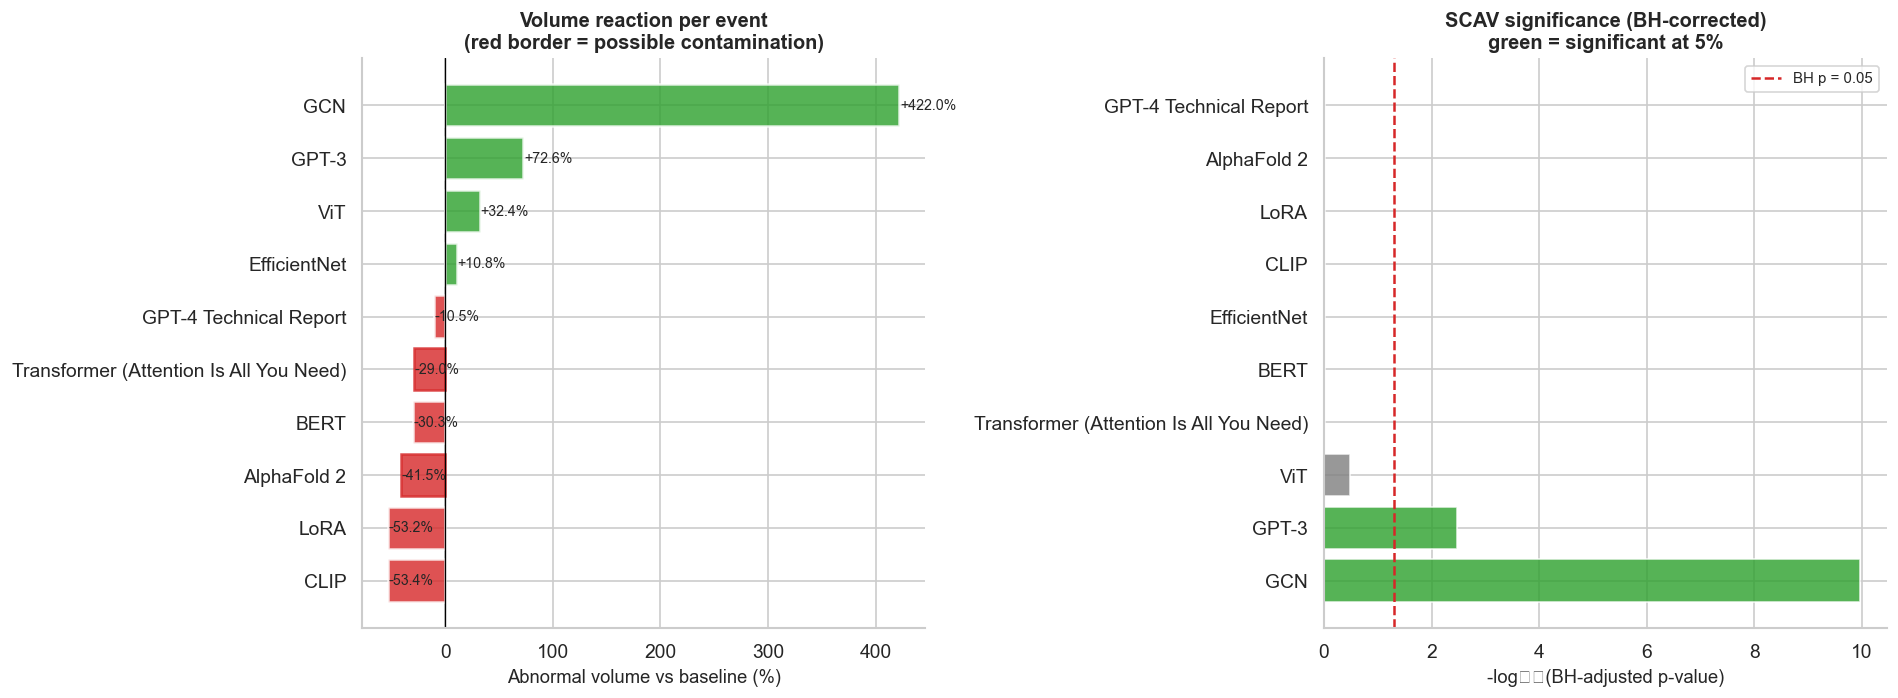

SCAV-significant events (BH p < 0.05): ['GCN', 'GPT-3']


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1 — Abnormal volume % sorted bar chart
prim_sorted = primary.sort_values('abnorm_vol_pct', ascending=True)
colors = [C_ACCENT if v > 0 else C_TREND for v in prim_sorted['abnorm_vol_pct']]
edge   = [C_TREND if row.contaminated else 'white'
          for _, row in prim_sorted.iterrows()]

axes[0].barh(prim_sorted['event'], prim_sorted['abnorm_vol_pct'],
             color=colors, alpha=0.8, edgecolor=edge, linewidth=1.5)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Abnormal volume vs baseline (%)', fontsize=11)
axes[0].set_title('Volume reaction per event\n(red border = possible contamination)',
                  fontsize=12, fontweight='bold')

for bar, (_, row) in zip(axes[0].patches, prim_sorted.iterrows()):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{row['abnorm_vol_pct']:+.1f}%", va='center', fontsize=8.5)

# Panel 2 — -log10(BH p-value) for SCAV
sig_sorted = primary.sort_values('scav_pval_bh', ascending=True)
neglog = -np.log10(np.clip(sig_sorted['scav_pval_bh'], 1e-12, 1.0))
bar_colors = [C_ACCENT if p < ALPHA else C_NEUTRAL
              for p in sig_sorted['scav_pval_bh']]

axes[1].barh(sig_sorted['event'], neglog, color=bar_colors, alpha=0.8)
axes[1].axvline(-np.log10(ALPHA), color=C_TREND, linestyle='--',
                linewidth=1.5, label=f'BH p = {ALPHA}')
axes[1].set_xlabel('-log₁₀(BH-adjusted p-value)', fontsize=11)
axes[1].set_title('SCAV significance (BH-corrected)\ngreen = significant at 5%',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

sig_events = primary[primary['scav_pval_bh'] < ALPHA]['event'].tolist()
print(f'SCAV-significant events (BH p < {ALPHA}): {sig_events if sig_events else "None"}')


## 7. Return Analysis: CAR (Cumulative Abnormal Returns)

This section is **new** relative to the original notebook. The volume analysis measures *attention*; the CAR analysis measures *price impact*.

**Interpretation:**
- Positive CAR → BOTZ outperformed its expected return (given QQQ) during the event window.
- Negative CAR → BOTZ underperformed. This is not necessarily bearish — it could mean investors rotated capital out of the ETF anticipating future gains elsewhere.
- Near-zero CAR with significant SCAV → high trading activity with no directional price impact (informed vs uninformed trading ambiguity).


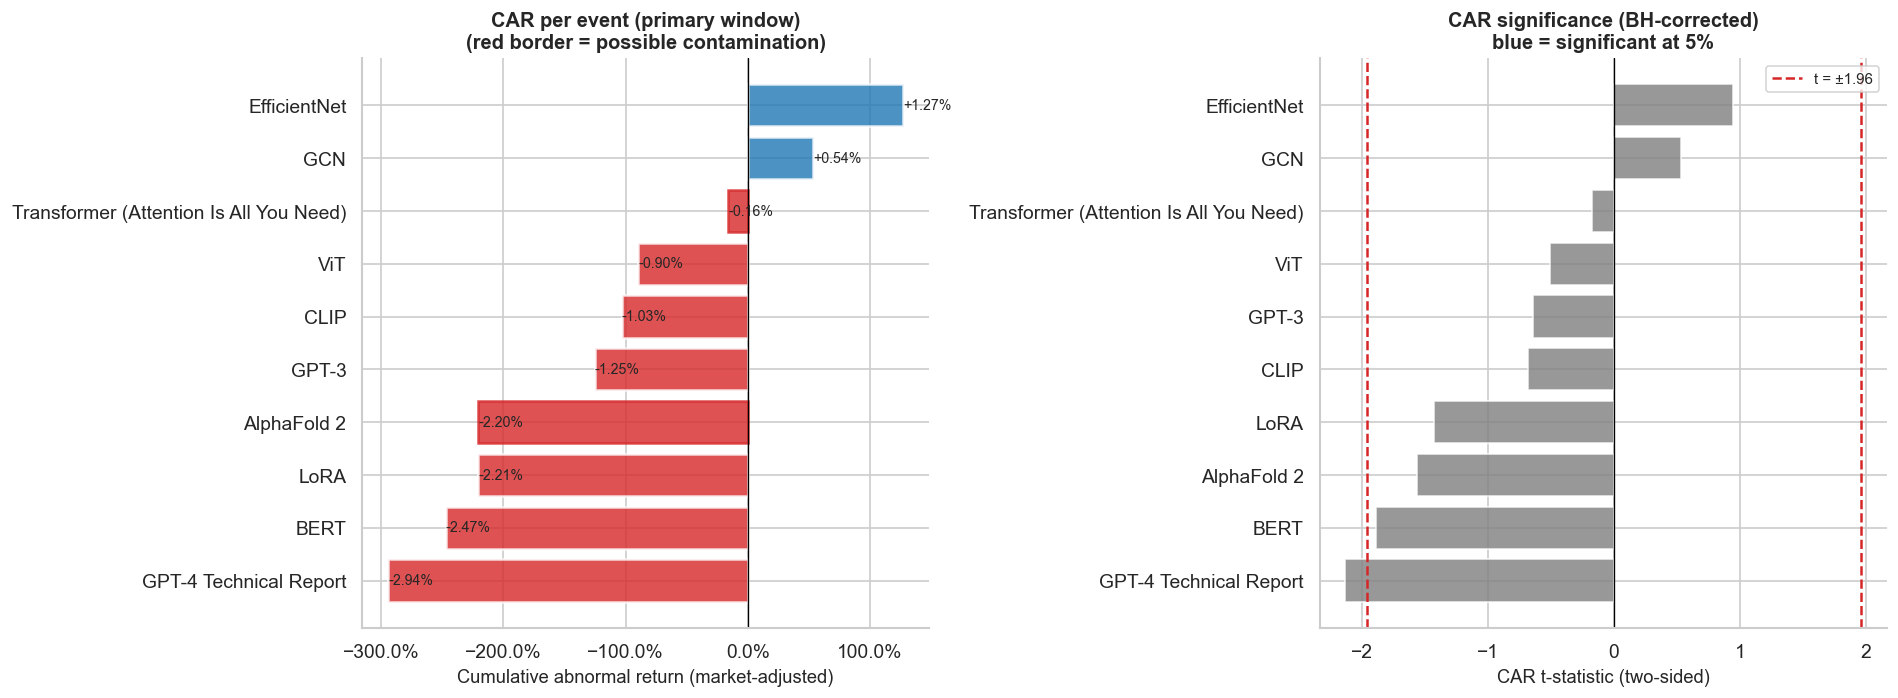

CAR-significant events (BH p < 0.05): None

VOLUME vs RETURN DIVERGENCE:
  Both significant      : None
  Volume only           : ['GCN', 'GPT-3']
  Return only           : None


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1 — CAR % sorted bar chart
car_sorted = primary.sort_values('car_pct', ascending=True)
colors = [C_ETF if v > 0 else C_TREND for v in car_sorted['car_pct']]
edge   = [C_TREND if row.contaminated else 'white'
          for _, row in car_sorted.iterrows()]

axes[0].barh(car_sorted['event'], car_sorted['car_pct'],
             color=colors, alpha=0.8, edgecolor=edge, linewidth=1.5)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
axes[0].set_xlabel('Cumulative abnormal return (market-adjusted)', fontsize=11)
axes[0].set_title('CAR per event (primary window)\n(red border = possible contamination)',
                  fontsize=12, fontweight='bold')

for bar, (_, row) in zip(axes[0].patches, car_sorted.iterrows()):
    axes[0].text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
                 f"{row['car_pct']:+.2f}%", va='center', fontsize=8.5)

# Panel 2 — CAR t-stat vs 0 (two-sided)
sig_sorted = primary.sort_values('car_tstat', ascending=True)
bar_colors = [C_ETF if p < ALPHA else C_NEUTRAL
              for p in sig_sorted['car_pval_bh']]

axes[1].barh(sig_sorted['event'], sig_sorted['car_tstat'],
             color=bar_colors, alpha=0.8)
axes[1].axvline(0,     color='black',  linewidth=0.8)
axes[1].axvline( 1.96, color=C_TREND,  linestyle='--', linewidth=1.5, label='t = ±1.96')
axes[1].axvline(-1.96, color=C_TREND,  linestyle='--', linewidth=1.5)
axes[1].set_xlabel('CAR t-statistic (two-sided)', fontsize=11)
axes[1].set_title('CAR significance (BH-corrected)\nblue = significant at 5%',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

car_sig = primary[primary['car_pval_bh'] < ALPHA]['event'].tolist()
print(f'CAR-significant events (BH p < {ALPHA}): {car_sig if car_sig else "None"}')
print()
print('VOLUME vs RETURN DIVERGENCE:')
diverge = primary.copy()
diverge['vol_sig'] = diverge['scav_pval_bh'] < ALPHA
diverge['car_sig'] = diverge['car_pval_bh']  < ALPHA
both   = diverge[diverge['vol_sig'] & diverge['car_sig']]['event'].tolist()
vol_no_car = diverge[diverge['vol_sig'] & ~diverge['car_sig']]['event'].tolist()
car_no_vol = diverge[~diverge['vol_sig'] & diverge['car_sig']]['event'].tolist()
print(f'  Both significant      : {both if both else "None"}')
print(f'  Volume only           : {vol_no_car if vol_no_car else "None"}')
print(f'  Return only           : {car_no_vol if car_no_vol else "None"}')


## 8. Multi-Window Robustness Check

A critical test: **do the findings hold across different event window definitions?**

If a result is robust, it should appear consistently across windows. A significant SCAV in [-1,1] that disappears in [-3,3] suggests the signal is confined to a very tight window — which could be genuine (markets react fast and revert) or a chance finding.

We compare the mean SCAV and mean CAR across the three window specifications.


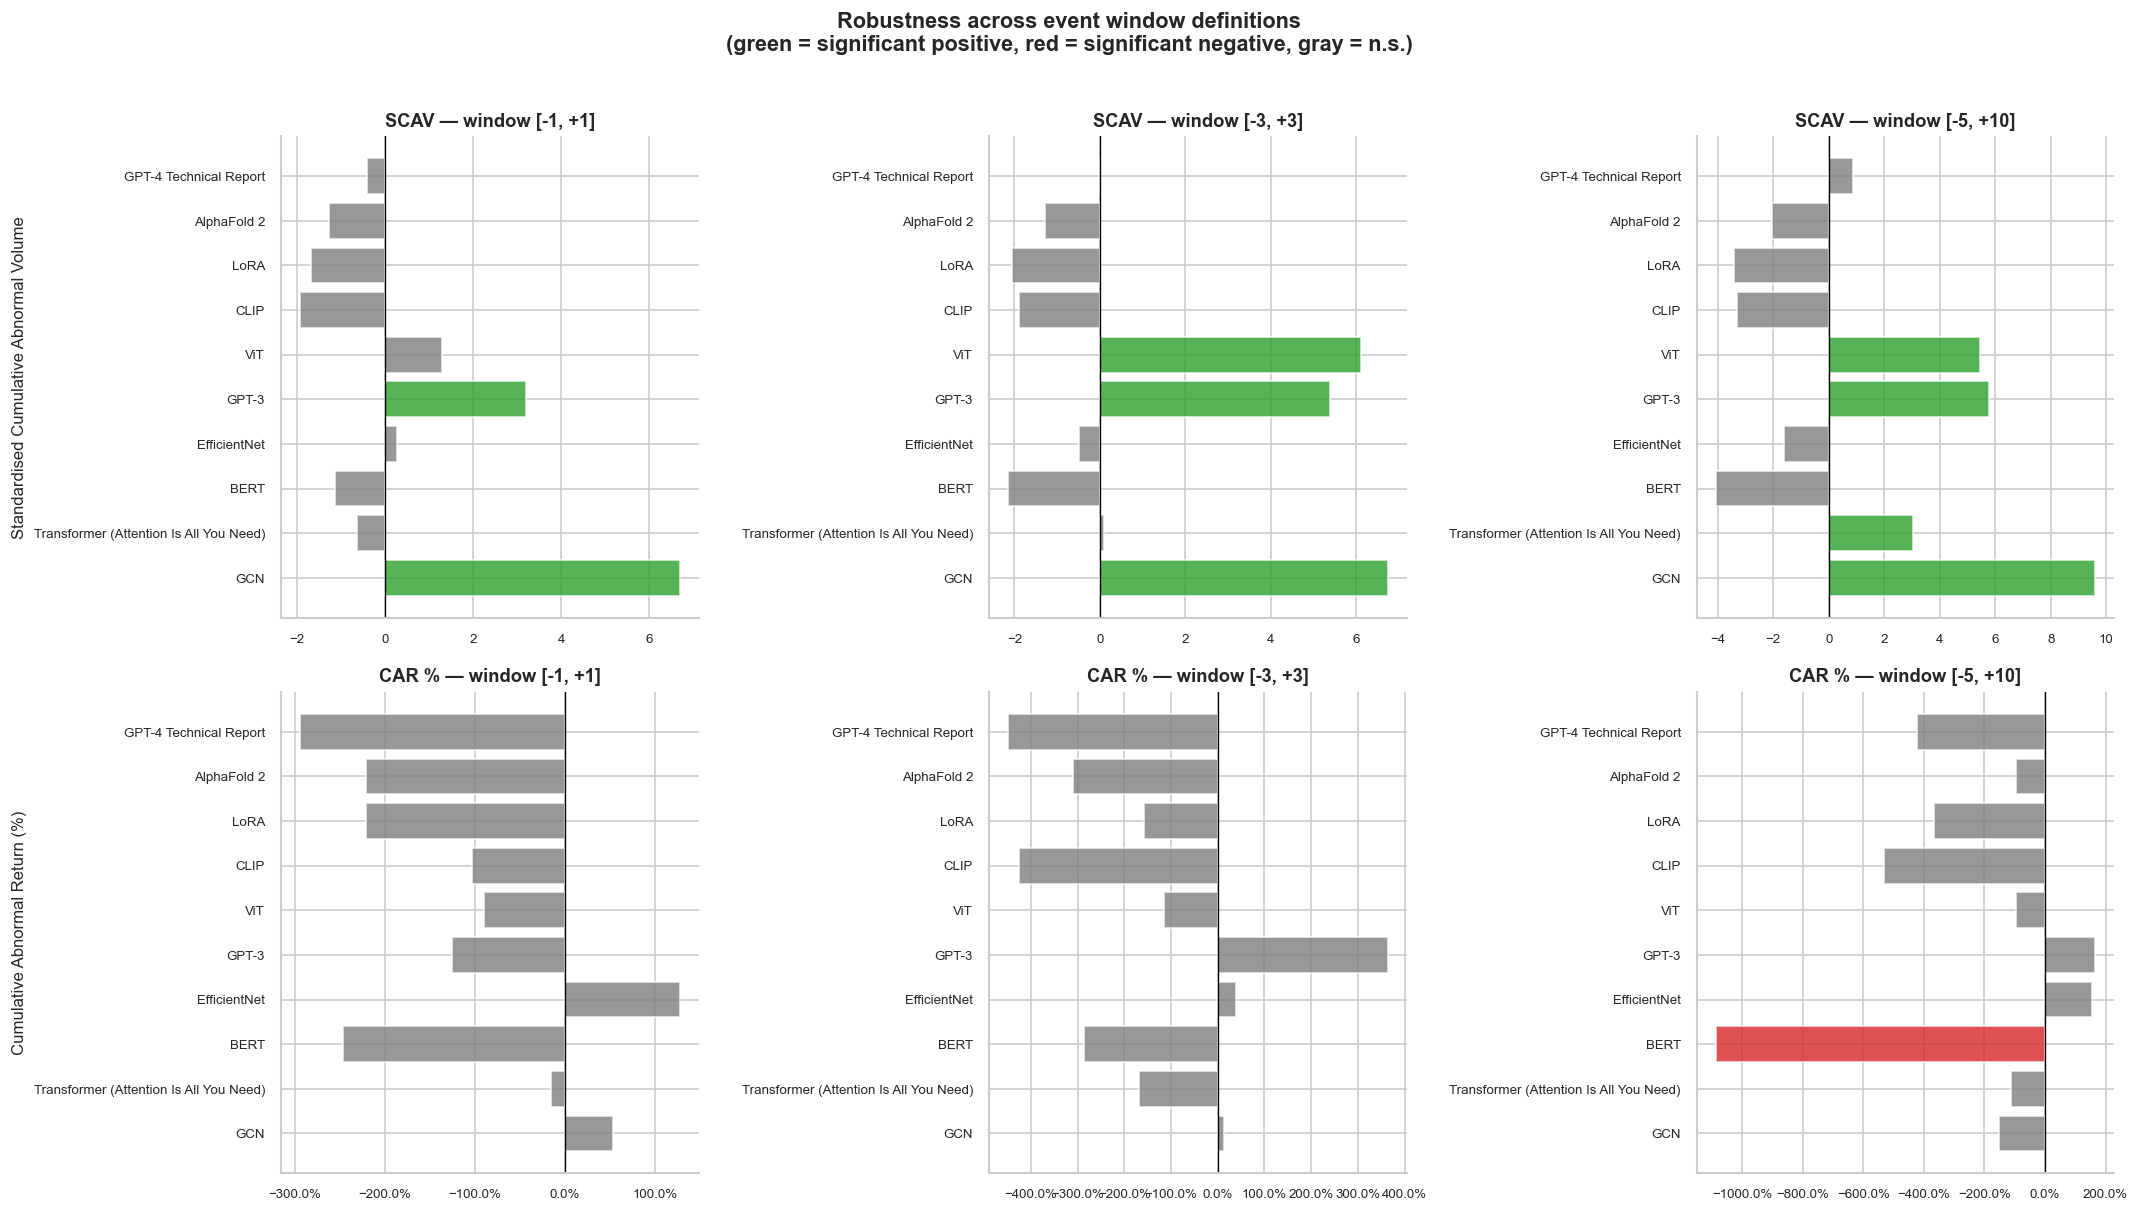

ROBUSTNESS SUMMARY
═══════════════════════════════════════════════════════
Window       SCAV sig     CAR sig     
────────────────────────────────────
[-1, +1]     2            0           
[-3, +3]     3            0           
[-5, +10]    4            1           


In [50]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

window_labels = ['[-1, +1]', '[-3, +3]', '[-5, +10]']
metrics = [
    ('scav',    'SCAV',  'Standardised Cumulative Abnormal Volume', C_PAPER),
    ('car_pct', 'CAR %', 'Cumulative Abnormal Return (%)',          C_ETF),
]

for row_idx, (metric, short, ylabel, color) in enumerate(metrics):
    for col_idx, (win, win_label) in enumerate(zip(EVENT_WINDOWS, window_labels)):
        ax = axes[row_idx][col_idx]
        win_str = f'[{win[0]},{win[1]}]'
        sub = results_df[results_df['window'] == win_str].sort_values('actual_date')
        
        bar_colors = []
        for _, r in sub.iterrows():
            pv_col = 'scav_pval_bh' if metric == 'scav' else 'car_pval_bh'
            if r[pv_col] < ALPHA:
                bar_colors.append(C_ACCENT if r[metric] > 0 else C_TREND)
            else:
                bar_colors.append(C_NEUTRAL)
        
        ax.barh(sub['event'], sub[metric], color=bar_colors, alpha=0.8, edgecolor='white')
        ax.axvline(0, color='black', linewidth=0.8)
        
        if metric == 'car_pct':
            ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
        
        ax.set_title(f'{short} — window {win_label}', fontsize=11, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=10)
        ax.tick_params(labelsize=8)

plt.suptitle('Robustness across event window definitions\n'
             '(green = significant positive, red = significant negative, gray = n.s.)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Summary table: how many events significant per window × metric
print('ROBUSTNESS SUMMARY')
print('═' * 55)
print(f'{"Window":<12} {"SCAV sig":<12} {"CAR sig":<12}')
print('─' * 36)
for win, win_label in zip(EVENT_WINDOWS, window_labels):
    win_str = f'[{win[0]},{win[1]}]'
    sub = results_df[results_df['window'] == win_str]
    n_scav = (sub['scav_pval_bh'] < ALPHA).sum()
    n_car  = (sub['car_pval_bh']  < ALPHA).sum()
    print(f'{win_label:<12} {n_scav:<12} {n_car:<12}')


## 9. Average Event-Time Plot (Canonical Event Study)

The canonical event study visualisation: **stack all events in event-time** (where t=0 is the event day) and plot the **average** metric over time. A confidence band (± 1.96 × SE) shows whether the average is distinguishable from noise.

This plot answers: "on average across all events, is there a systematic shift in volume or returns around t=0?"

Methodology:
- For each event, extract the event-time series from t−5 to t+10.
- Align all events on t=0.
- Compute the cross-sectional mean and SE at each event-time offset.
- Plot mean ± 1.96 SE.


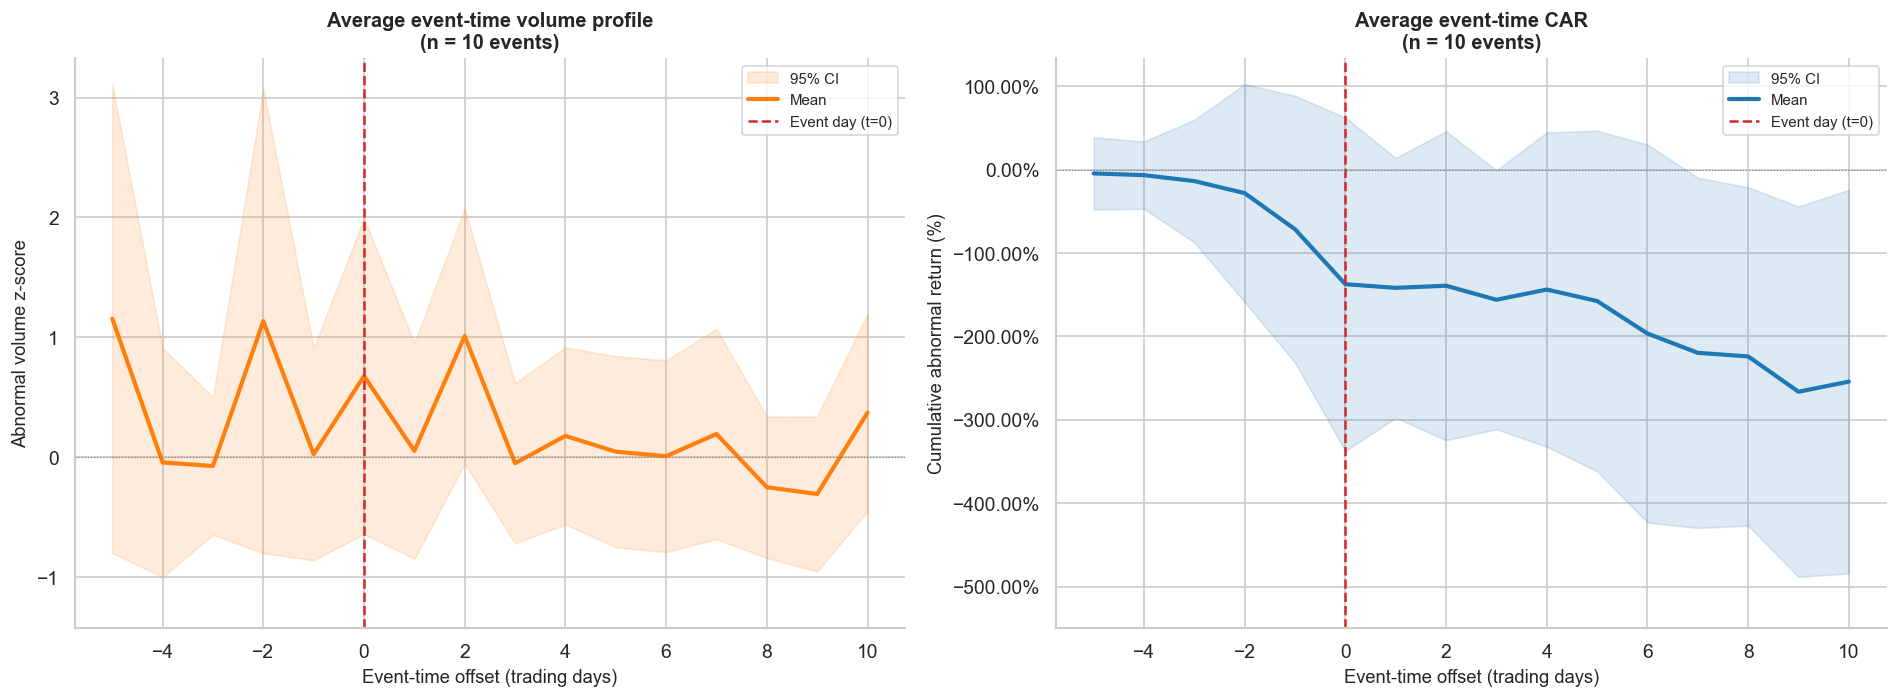


HOW TO READ THIS PLOT
─────────────────────
A flat line centred on 0 = no average event effect.
A peak at t=0 (or t=+1) in the volume plot = systematic jump in trading activity
  on/after event days.
A positive slope in the CAR plot post-event = sustained positive price drift
  after the news is absorbed; a V-shape = initial overreaction and reversal.



In [51]:
PRE_WINDOW  = 5
POST_WINDOW = 10

def extract_event_time_series(market_df, event_name, event_date,
                               pre=PRE_WINDOW, post=POST_WINDOW,
                               est_lookback=ESTIMATION_LOOKBACK,
                               est_gap=ESTIMATION_GAP):
    """
    Extract day-by-day abnormal volume z-score and abnormal return
    centred on the event day.
    """
    idx      = market_df.index
    req_date = pd.to_datetime(event_date)
    act_date = first_trading_day_on_or_after(idx, req_date)
    if act_date is None:
        return None

    t         = idx.get_loc(act_date)
    est_start = t - est_lookback
    est_end   = t - est_gap
    win_start = t - pre
    win_end   = t + post + 1

    if est_start < 0 or est_end <= est_start or win_start < 0 or win_end > len(market_df):
        return None

    est = market_df.iloc[est_start:est_end]
    win = market_df.iloc[win_start:win_end]

    # Volume z-score
    vol_mean = est['vol_ratio'].mean()
    vol_std  = est['vol_ratio'].std(ddof=1)
    if vol_std == 0:
        return None
    vol_z = (win['vol_ratio'] - vol_mean) / vol_std

    # Abnormal return via OLS market model
    X_est = np.column_stack([np.ones(len(est)), est['qqq_return'].values])
    y_est = est['botz_return'].values
    beta, _, _, _ = np.linalg.lstsq(X_est, y_est, rcond=None)
    ar_win = (win['botz_return'].values
              - (beta[0] + beta[1] * win['qqq_return'].values))

    # Cumulative abnormal return day by day
    car_cum = np.cumsum(ar_win) * 100   # in %

    offsets = np.arange(-pre, post + 1)
    return pd.DataFrame({'offset': offsets,
                          'vol_z' : vol_z.values,
                          'ar'    : ar_win * 100,
                          'car'   : car_cum,
                          'event' : event_name})


# Collect all event-time series
ts_list = []
for e in PAPER_EVENTS:
    ts = extract_event_time_series(market_df, e['name'], e['date'])
    if ts is not None:
        ts_list.append(ts)

all_ts = pd.concat(ts_list, ignore_index=True)
n_events = all_ts['event'].nunique()

# Aggregate: mean and SE per offset
def agg_metric(df, metric):
    g = df.groupby('offset')[metric].agg(['mean', 'std', 'count'])
    g['se']   = g['std'] / np.sqrt(g['count'])
    g['lo95'] = g['mean'] - 1.96 * g['se']
    g['hi95'] = g['mean'] + 1.96 * g['se']
    return g

vol_agg = agg_metric(all_ts, 'vol_z')
car_agg = agg_metric(all_ts, 'car')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def plot_event_time(ax, agg, ylabel, color, title):
    x = agg.index.values
    ax.fill_between(x, agg['lo95'], agg['hi95'],
                    color=color, alpha=0.15, label='95% CI')
    ax.plot(x, agg['mean'], color=color, linewidth=2.5, label='Mean')
    ax.axvline(0, color=C_TREND, linestyle='--', linewidth=1.5, label='Event day (t=0)')
    ax.axhline(0, color='gray', linewidth=0.7, linestyle=':')
    ax.fill_between(x, ax.get_ylim()[0] if ax.get_ylim()[0] < 0 else 0,
                    0, alpha=0)   # reset y-bounds; done by autoscale
    ax.set_xlabel('Event-time offset (trading days)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{title}\n(n = {n_events} events)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plot_event_time(axes[0], vol_agg, 'Abnormal volume z-score', C_PAPER,
                'Average event-time volume profile')
plot_event_time(axes[1], car_agg, 'Cumulative abnormal return (%)', C_ETF,
                'Average event-time CAR')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=2))

plt.tight_layout()
plt.show()

print("""
HOW TO READ THIS PLOT
─────────────────────
A flat line centred on 0 = no average event effect.
A peak at t=0 (or t=+1) in the volume plot = systematic jump in trading activity
  on/after event days.
A positive slope in the CAR plot post-event = sustained positive price drift
  after the news is absorbed; a V-shape = initial overreaction and reversal.
"""
)


## 10. Micro Event Charts

Individual event windows: **BOTZ price, abnormal return, and volume** in a single 3-panel figure. The layout follows the visual convention of 01_EDA (green = positive, red = negative, shared x-axis).


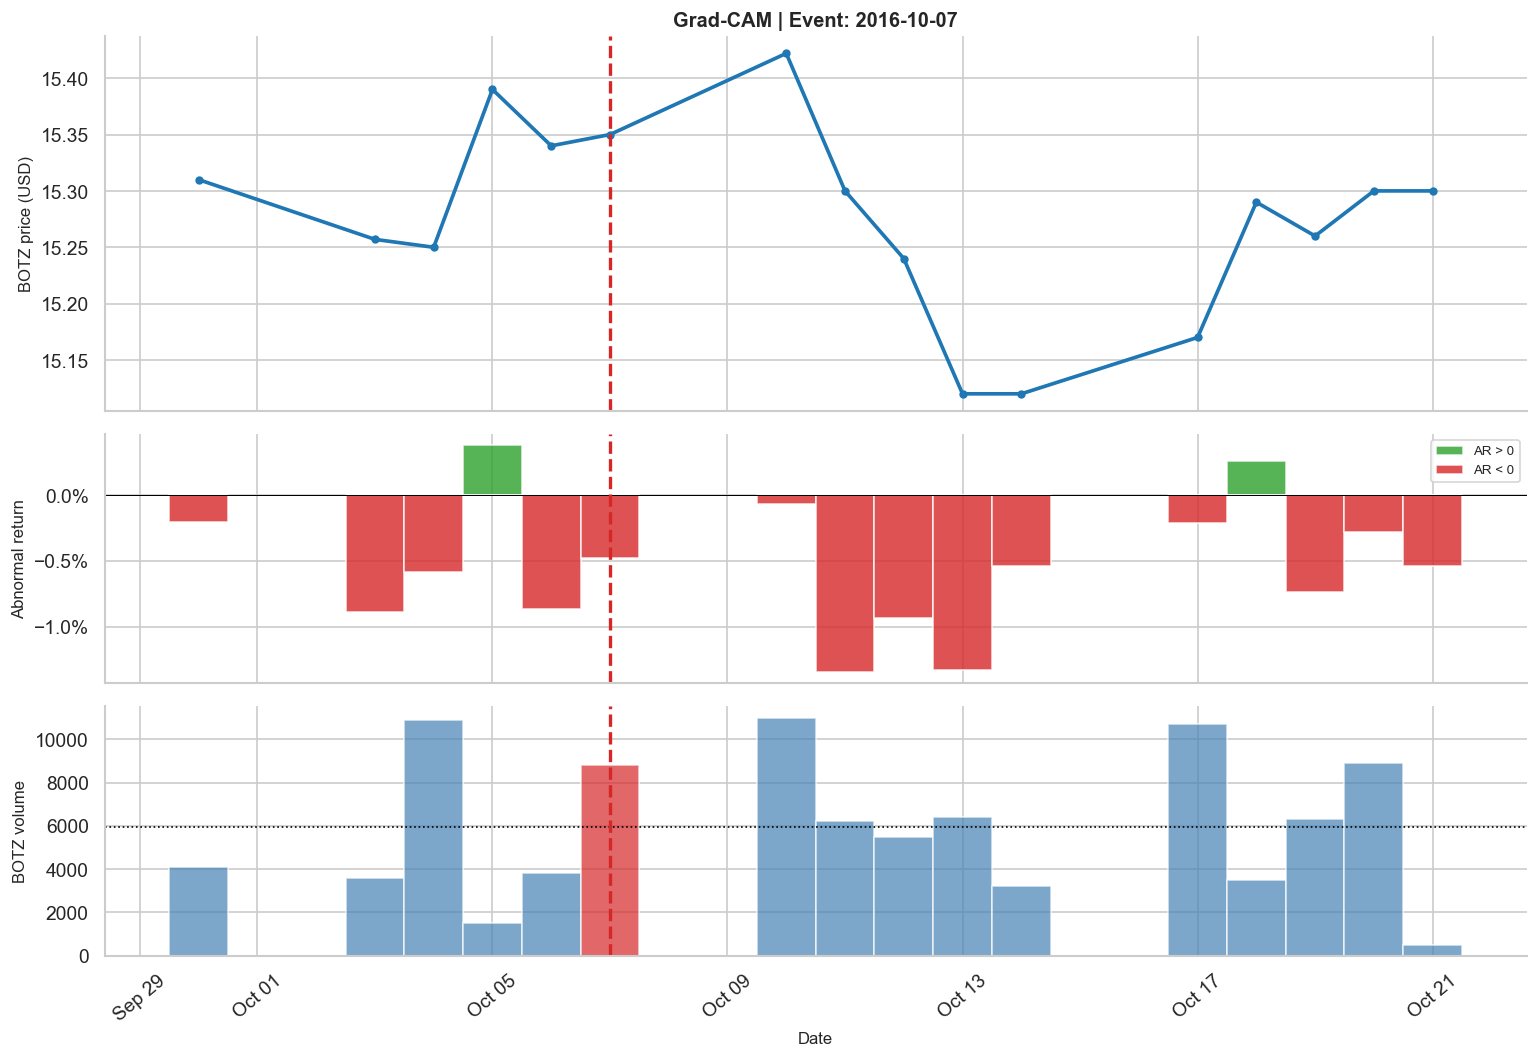

  CAR [-5, +10]: -8.37%   Volume jump on event day: +48.4%


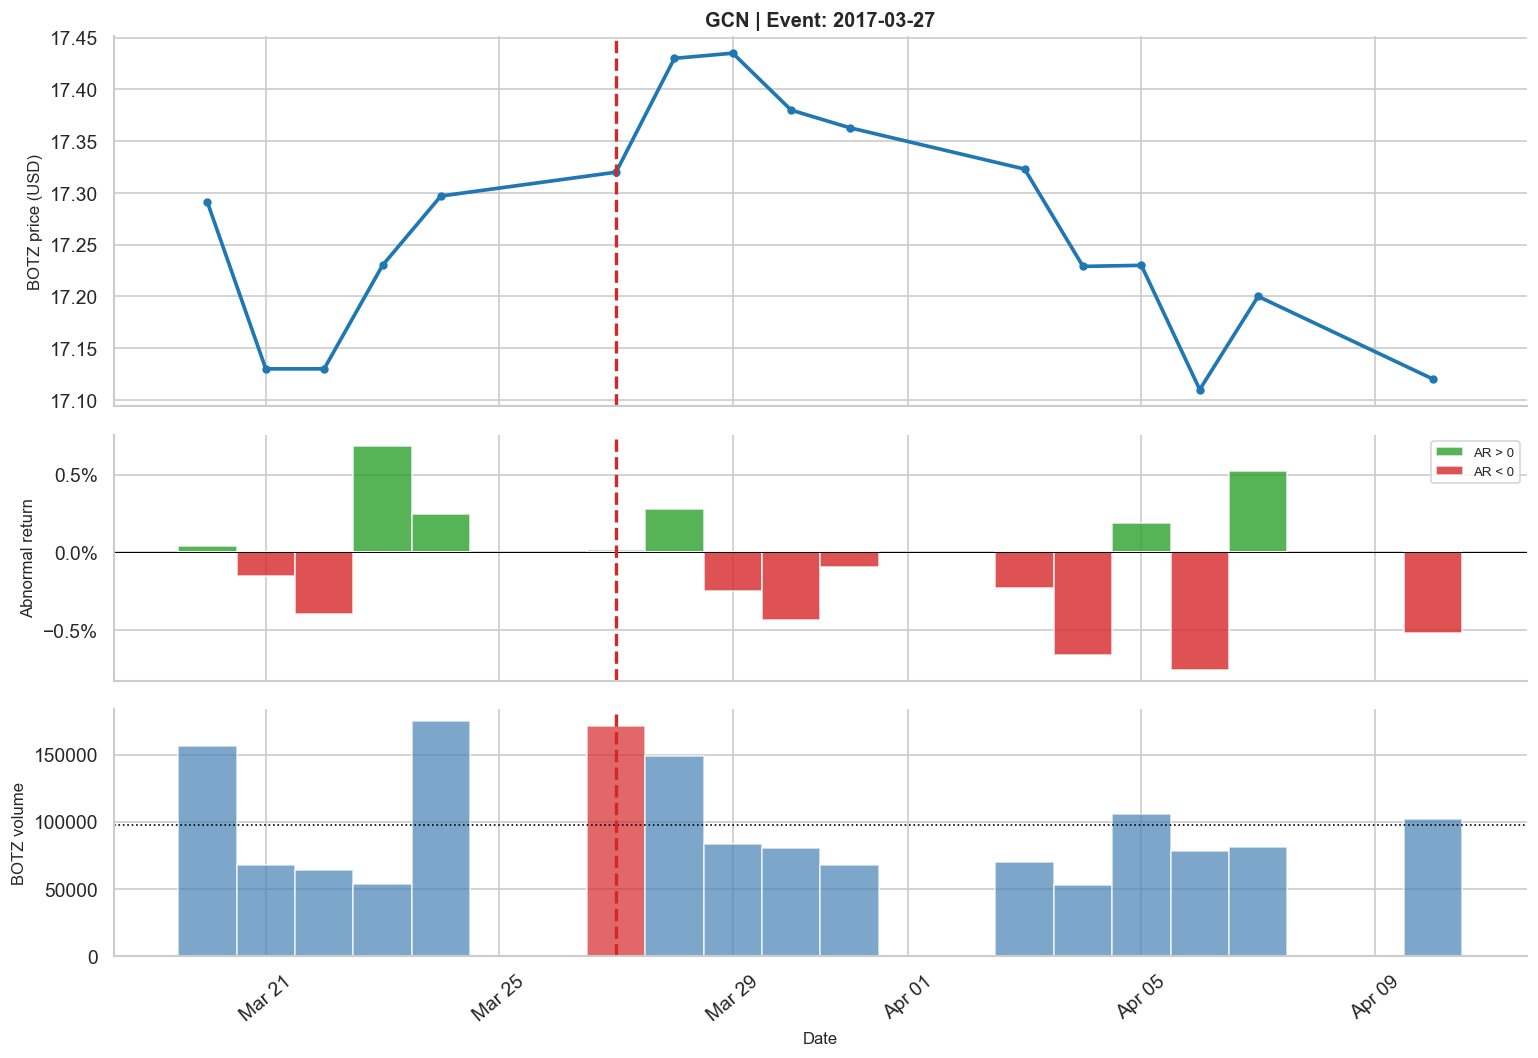

  CAR [-5, +10]: -1.52%   Volume jump on event day: +75.4%


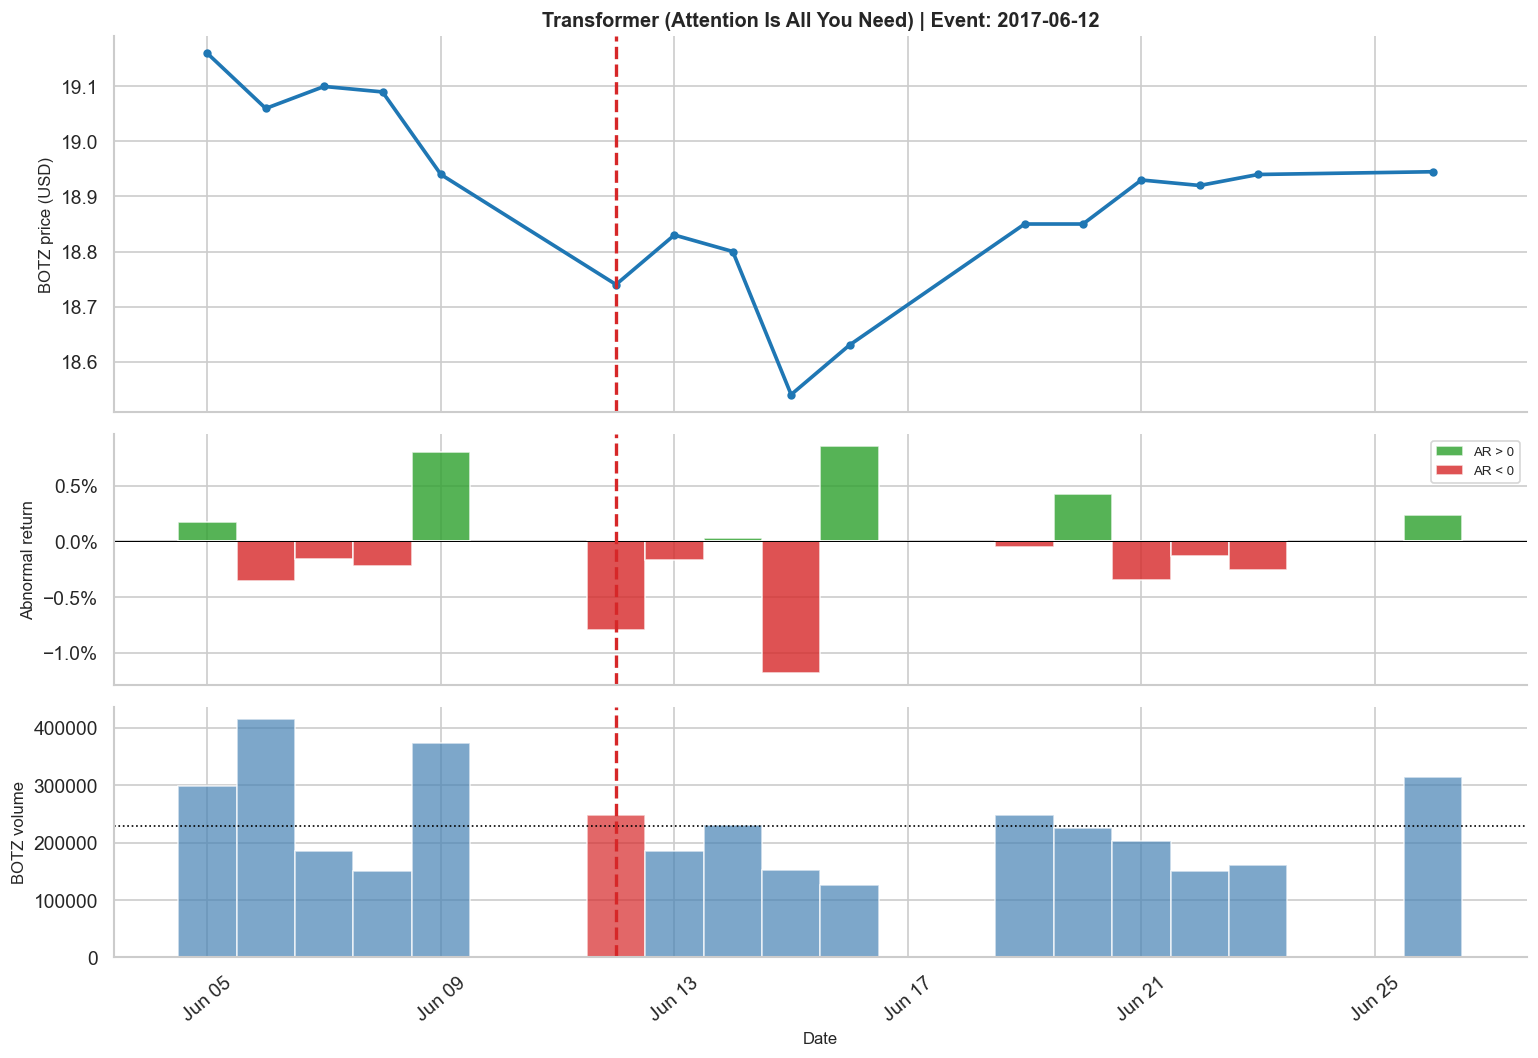

  CAR [-5, +10]: -1.12%   Volume jump on event day: +8.0%


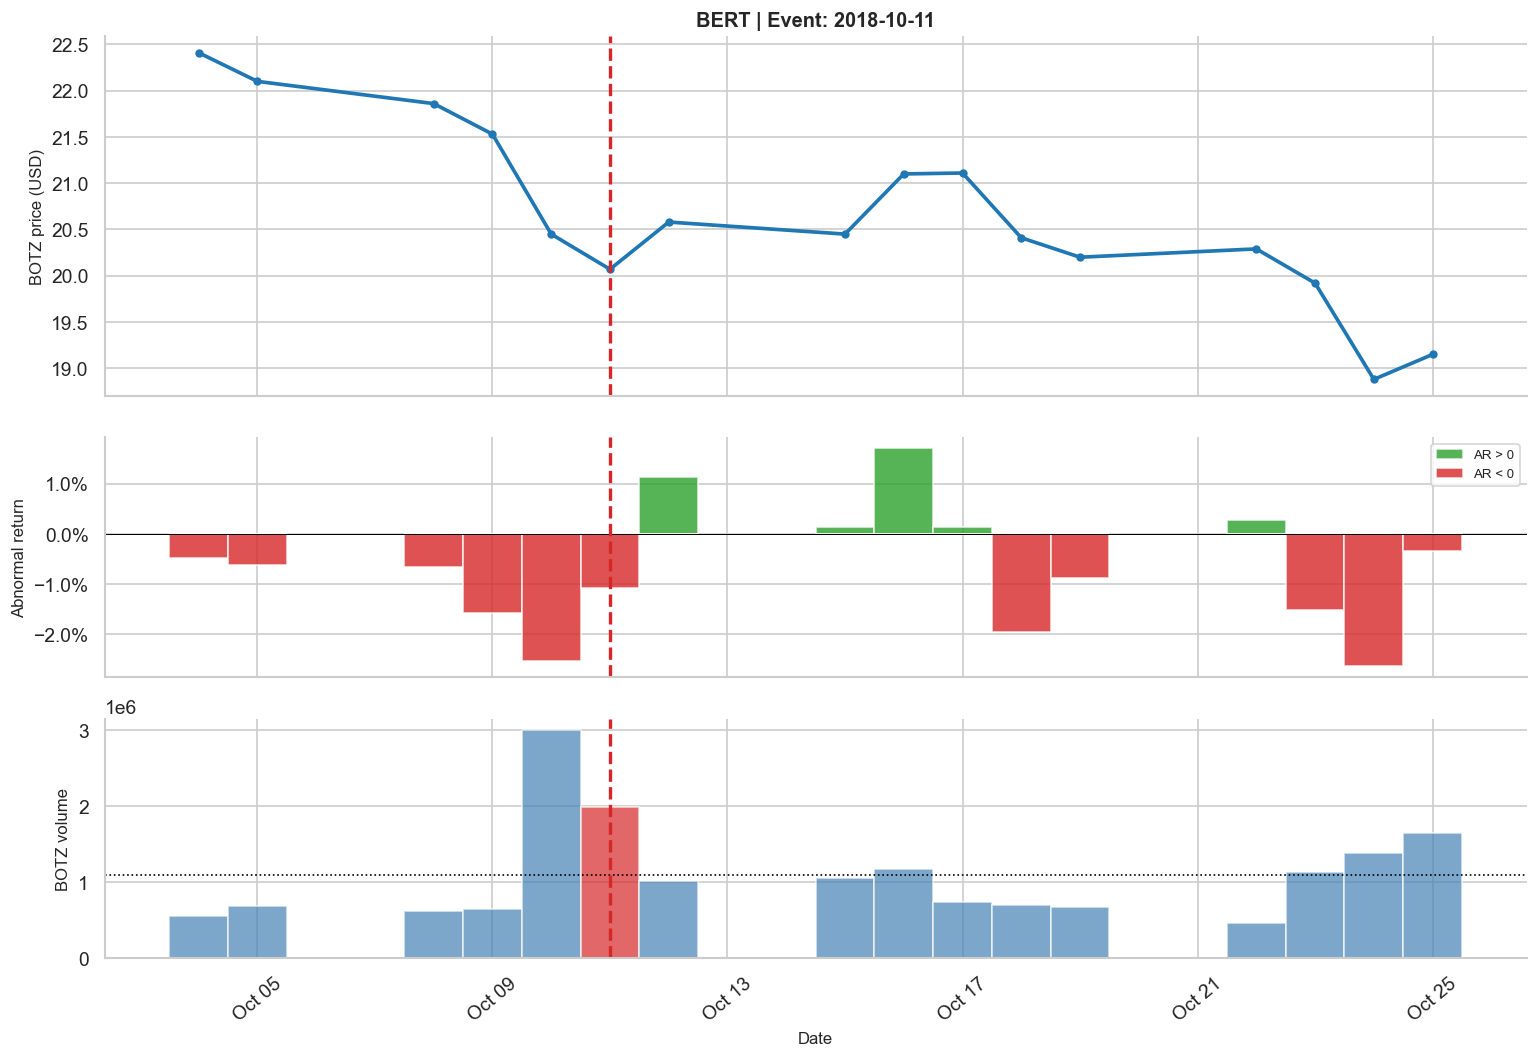

  CAR [-5, +10]: -10.88%   Volume jump on event day: +82.5%


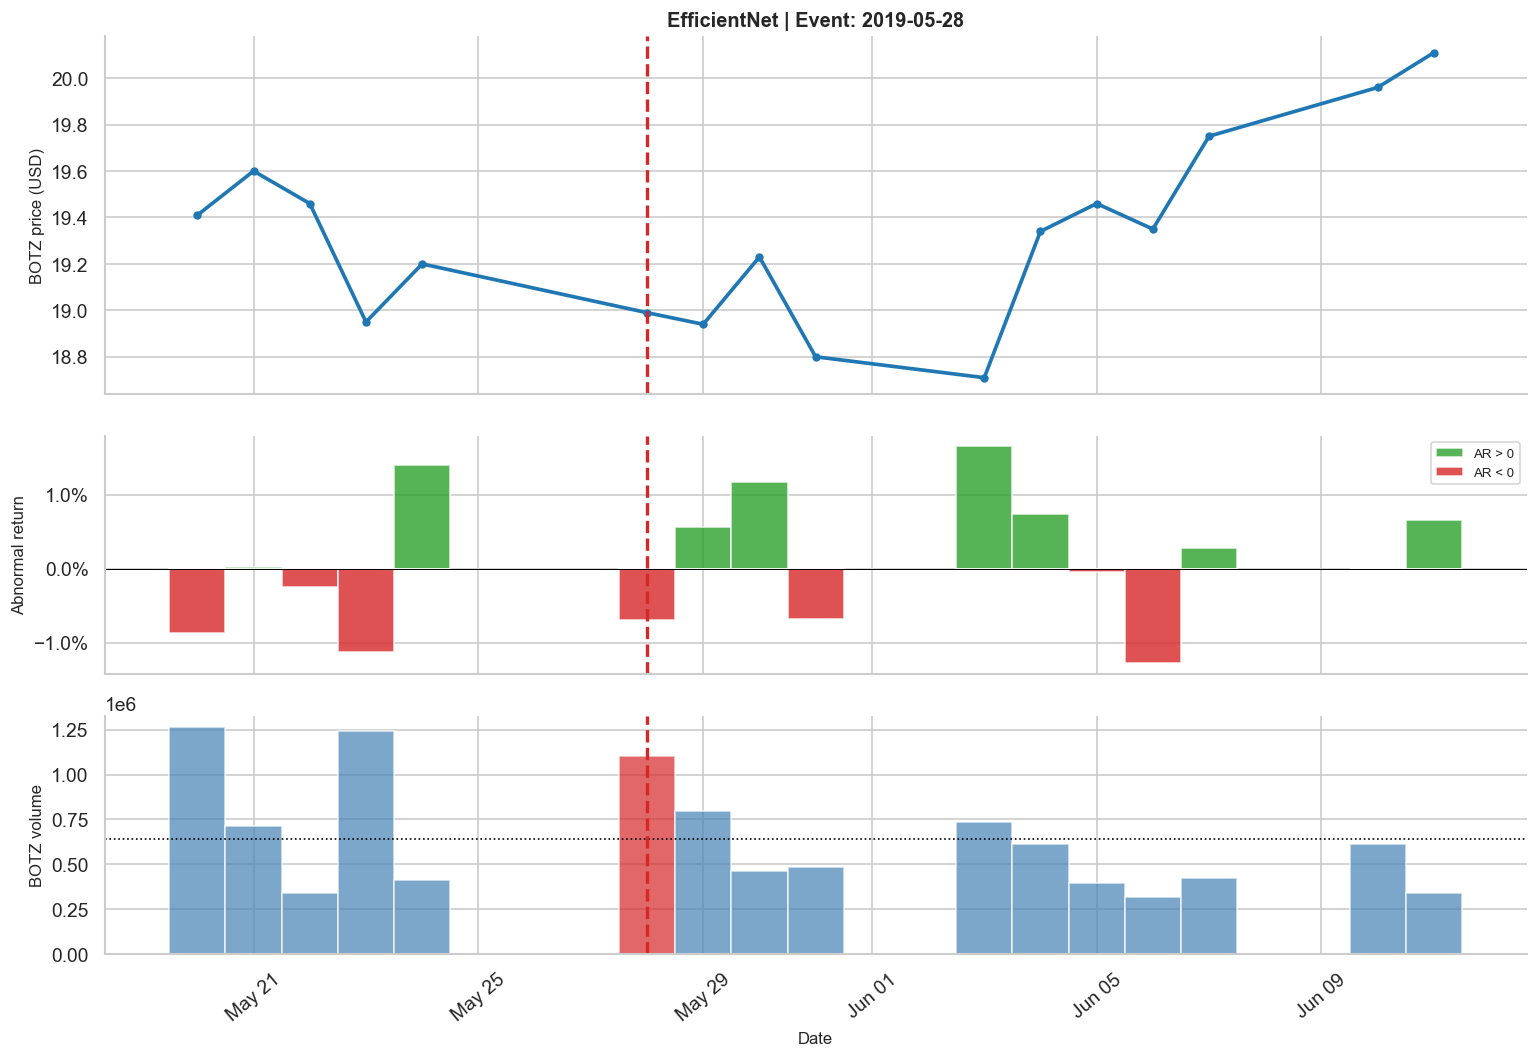

  CAR [-5, +10]: +1.56%   Volume jump on event day: +71.9%


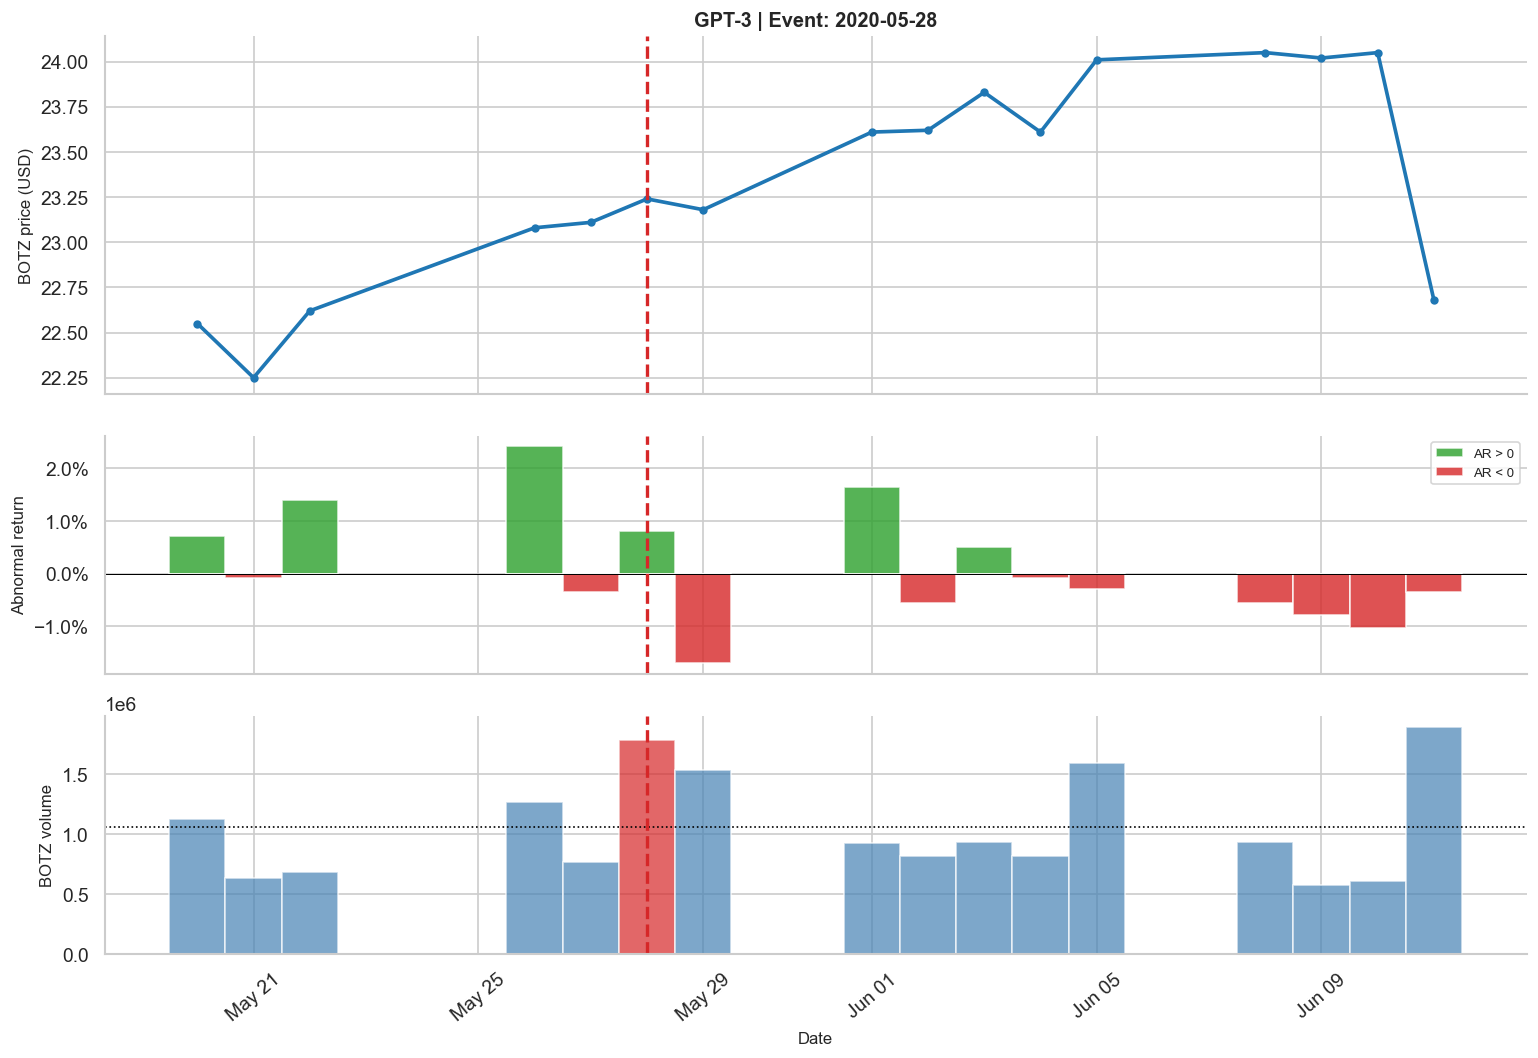

  CAR [-5, +10]: +1.66%   Volume jump on event day: +68.5%


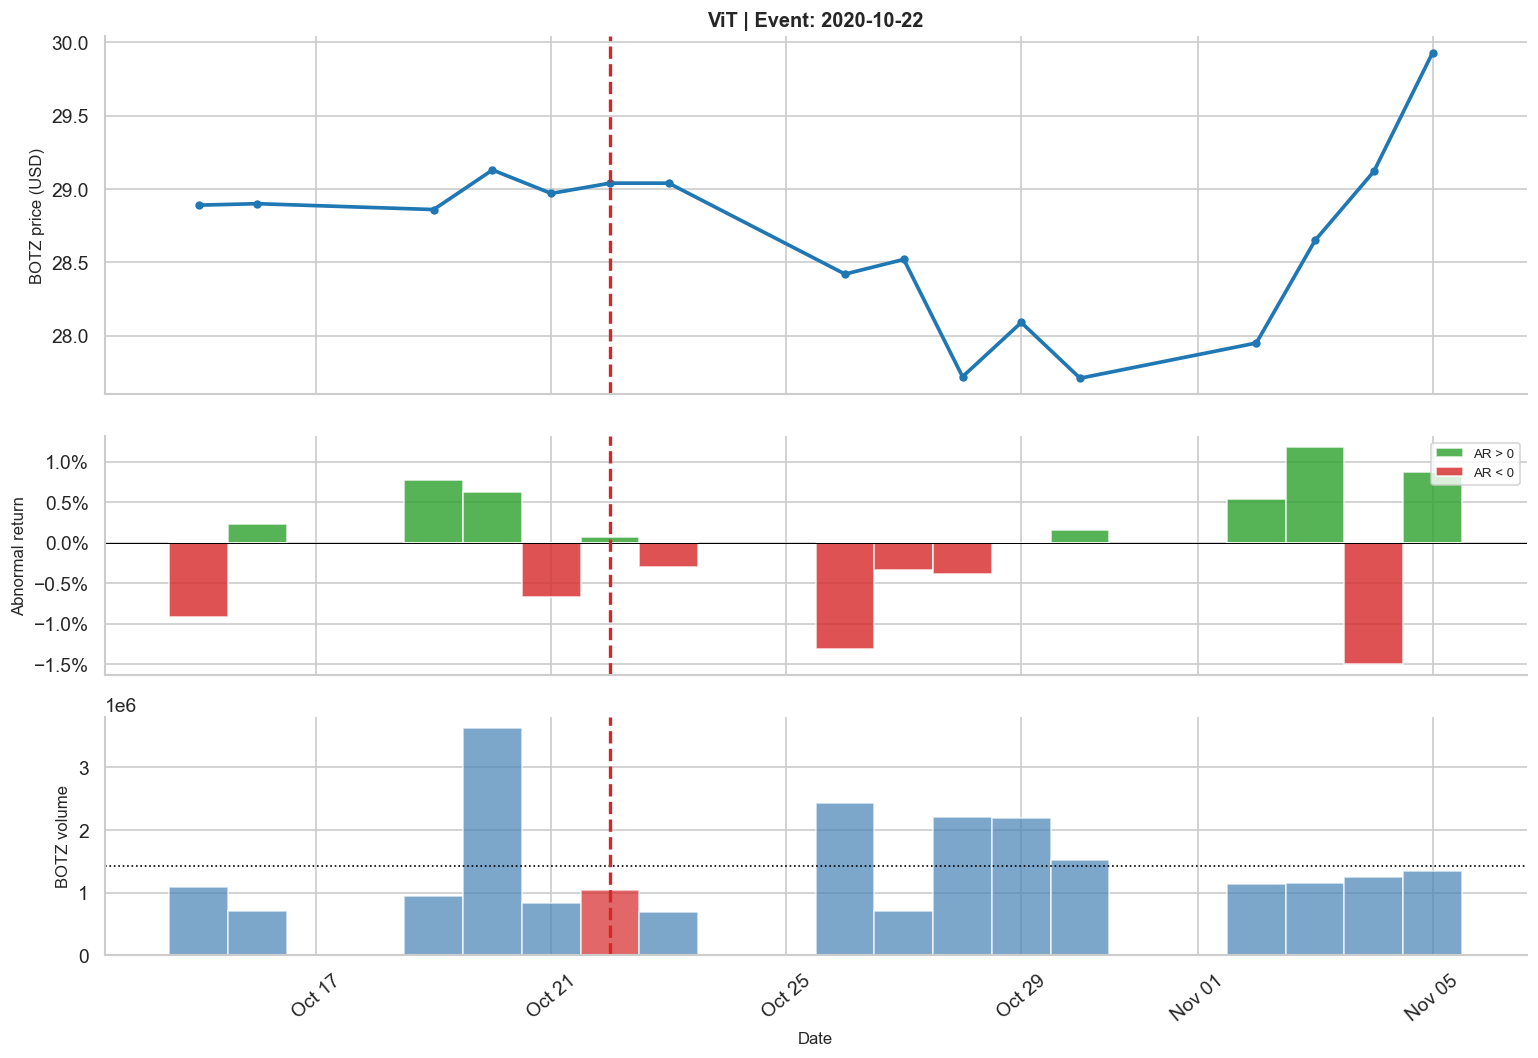

  CAR [-5, +10]: -0.96%   Volume jump on event day: -27.5%


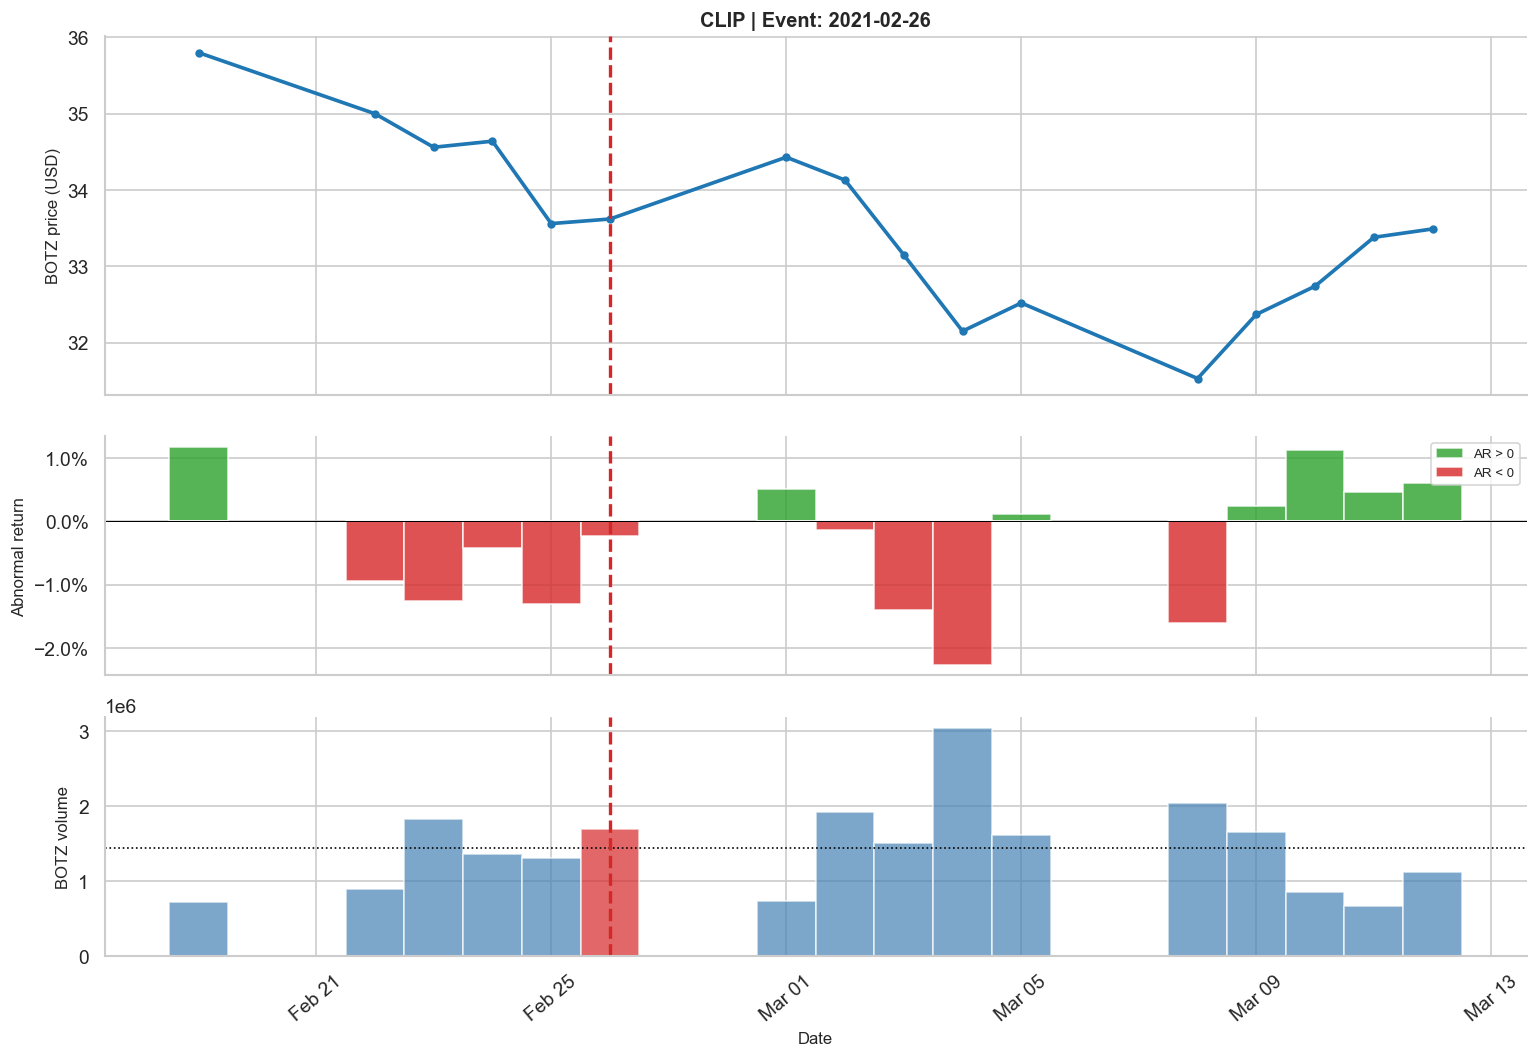

  CAR [-5, +10]: -5.33%   Volume jump on event day: +18.3%


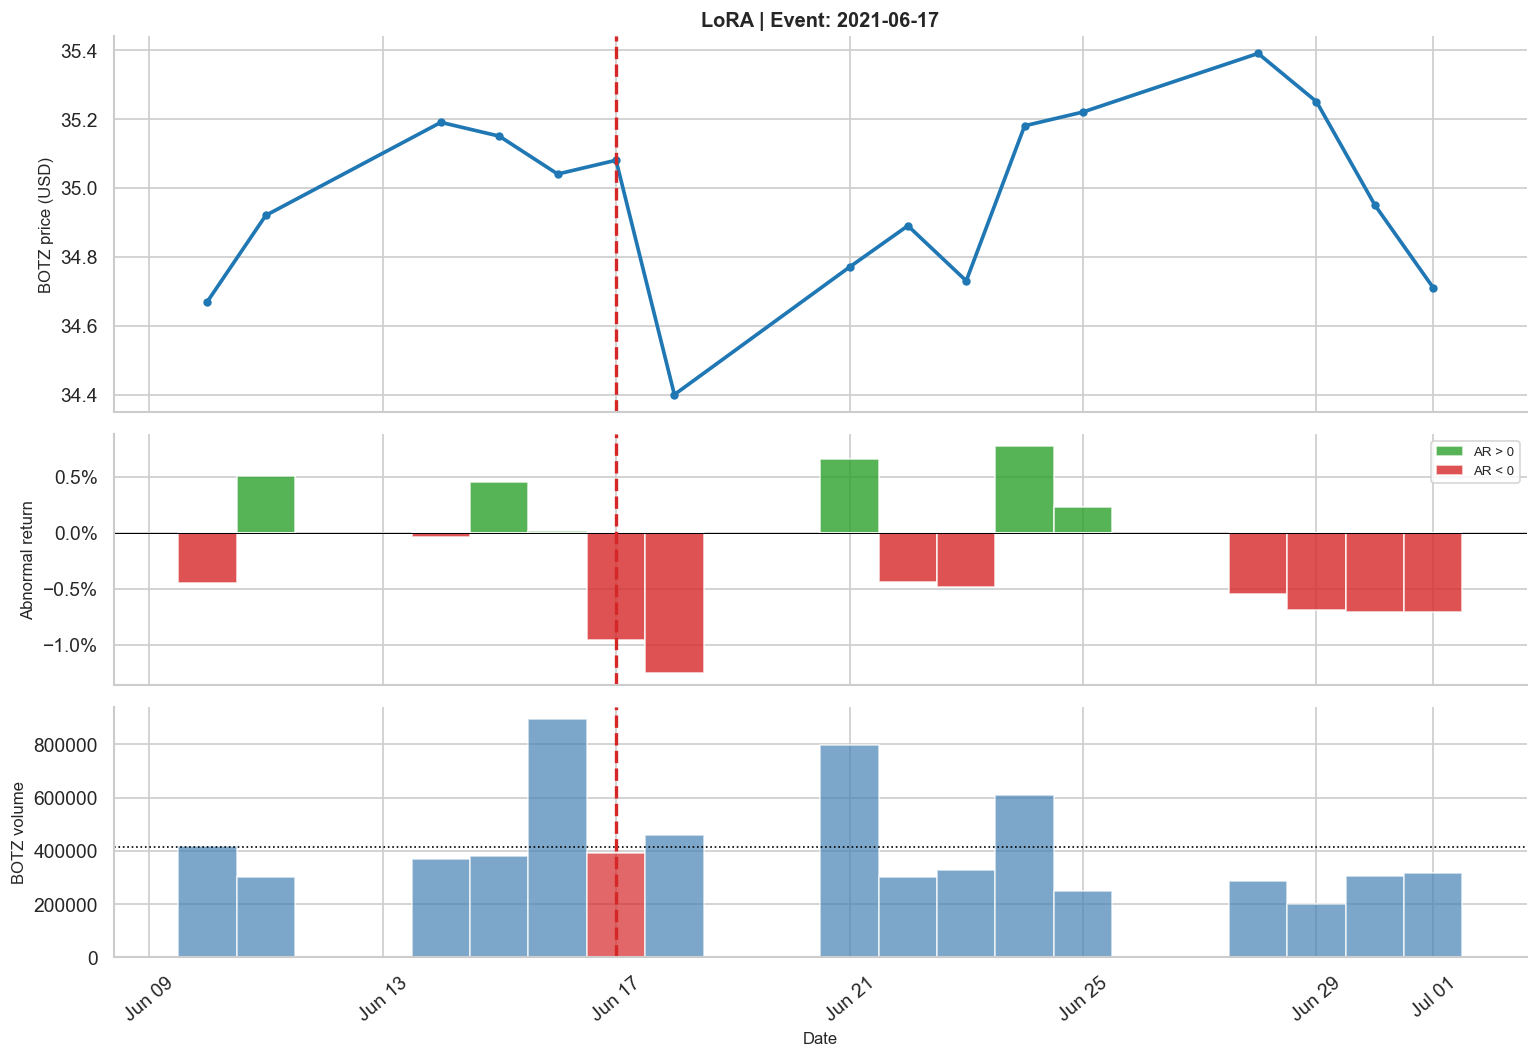

  CAR [-5, +10]: -3.65%   Volume jump on event day: -4.7%


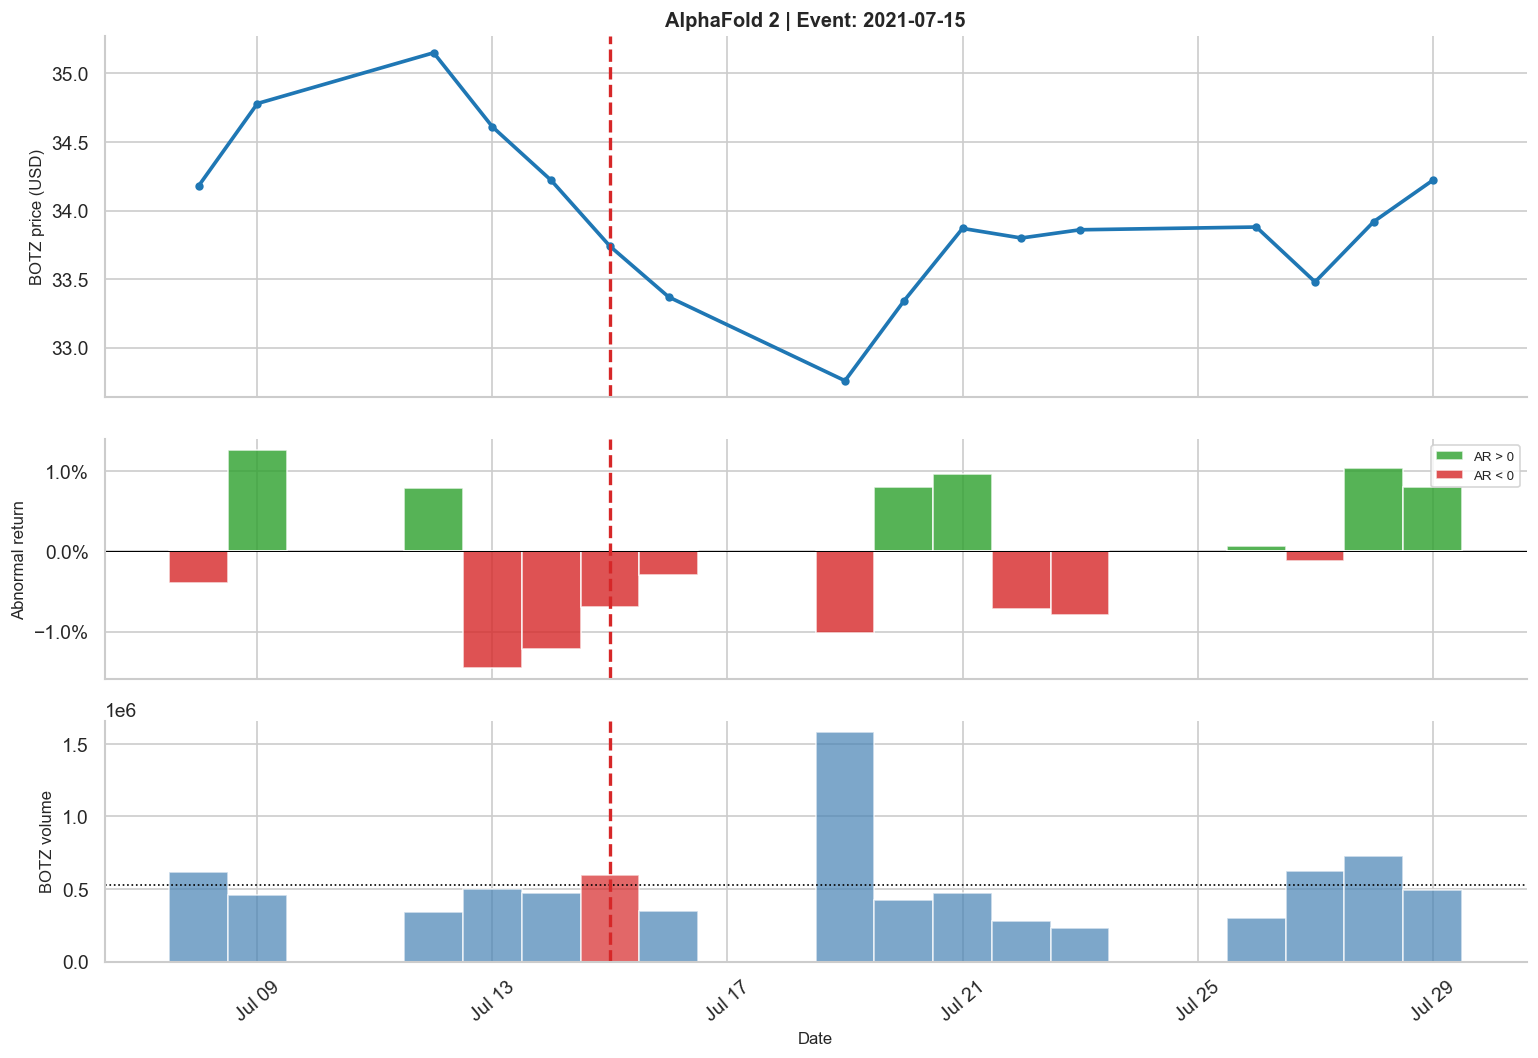

  CAR [-5, +10]: -0.97%   Volume jump on event day: +12.2%


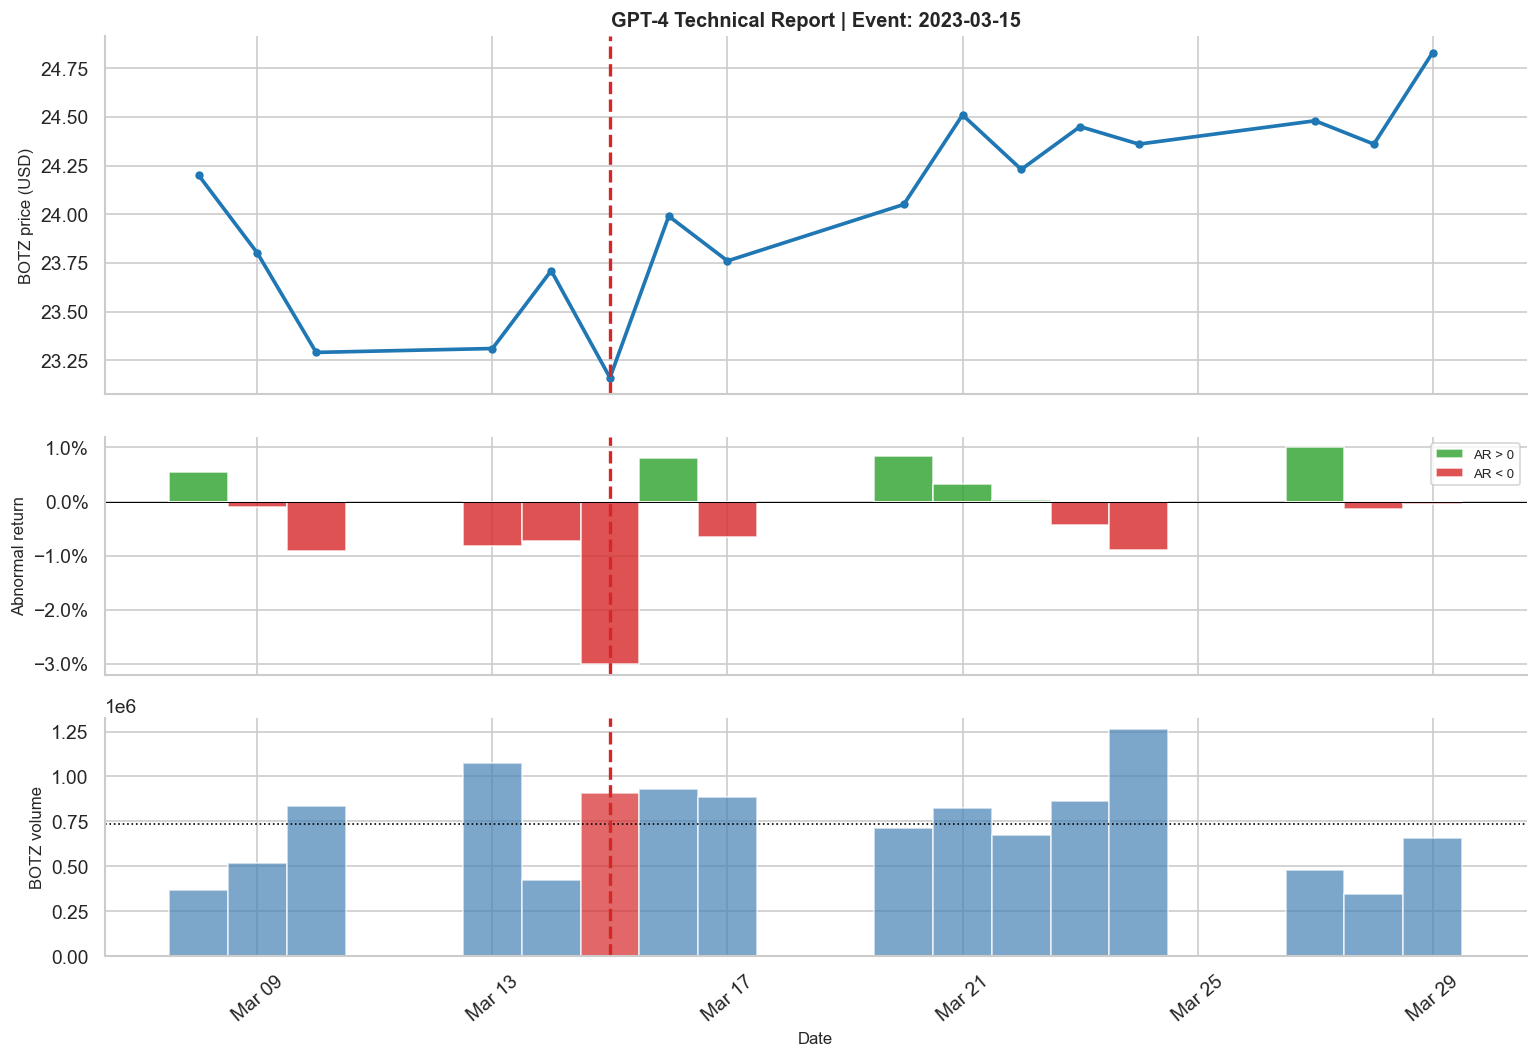

  CAR [-5, +10]: -4.22%   Volume jump on event day: +23.7%


In [52]:
def plot_micro_event(event_name: str, event_date_str: str,
                     pre_days: int = 5, post_days: int = 10):
    """
    Three-panel event window chart: price / abnormal return / volume.
    Uses market model to compute abnormal returns consistently with Section 7.
    """
    req_date = pd.to_datetime(event_date_str)
    dl_start = (req_date - pd.Timedelta(days=(ESTIMATION_LOOKBACK + pre_days + 20) * 2)).strftime('%Y-%m-%d')
    dl_end   = (req_date + pd.Timedelta(days=(post_days + 10) * 2)).strftime('%Y-%m-%d')

    data = download_market_data(dl_start, dl_end)
    if data.empty:
        print(f'No data for {event_name}')
        return

    act_date = first_trading_day_on_or_after(data.index, req_date)
    if act_date is None:
        print(f'Event date out of range: {event_name}')
        return

    t         = data.index.get_loc(act_date)
    est_start = max(0, t - ESTIMATION_LOOKBACK)
    est_end   = t - ESTIMATION_GAP
    win_start = max(0, t - pre_days)
    win_end   = min(len(data), t + post_days + 1)

    est  = data.iloc[est_start:est_end]
    win  = data.iloc[win_start:win_end]

    # Market model fit on estimation window
    X_est = np.column_stack([np.ones(len(est)), est['qqq_return'].values])
    beta, _, _, _ = np.linalg.lstsq(X_est, est['botz_return'].values, rcond=None)
    win_ar = (win['botz_return'].values
              - (beta[0] + beta[1] * win['qqq_return'].values))

    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True,
                             gridspec_kw={'height_ratios': [3, 2, 2]})

    dates = win.index
    offset = (dates - act_date).days

    # Panel 1 — Price
    axes[0].plot(dates, win['botz_close'], marker='o', linewidth=2.2,
                 color=C_ETF, markersize=4)
    axes[0].axvline(act_date, color=C_TREND, linestyle='--', linewidth=2)
    axes[0].set_ylabel('BOTZ price (USD)', fontsize=10)
    axes[0].set_title(f'{event_name} | Event: {act_date.date()}',
                      fontsize=12, fontweight='bold')

    # Panel 2 — Abnormal return
    pos = np.where(win_ar >= 0, win_ar, 0)
    neg = np.where(win_ar <  0, win_ar, 0)
    axes[1].bar(dates, pos, color=C_ACCENT, alpha=0.8, width=1, label='AR > 0')
    axes[1].bar(dates, neg, color=C_TREND,  alpha=0.8, width=1, label='AR < 0')
    axes[1].axhline(0, color='black', linewidth=0.6)
    axes[1].axvline(act_date, color=C_TREND, linestyle='--', linewidth=2)
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    axes[1].set_ylabel('Abnormal return', fontsize=10)
    axes[1].legend(fontsize=8, loc='upper right')

    # Panel 3 — Volume (colour event day)
    bar_colors = [C_TREND if d == act_date else 'steelblue' for d in dates]
    axes[2].bar(dates, win['botz_volume'], color=bar_colors, alpha=0.7, width=1)
    axes[2].axhline(win['botz_volume'].mean(), color='black', linestyle=':', linewidth=1)
    axes[2].axvline(act_date, color=C_TREND, linestyle='--', linewidth=2)
    axes[2].set_ylabel('BOTZ volume', fontsize=10)
    axes[2].set_xlabel('Date', fontsize=10)

    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=40)
    plt.tight_layout()
    plt.show()

    car_event = win_ar.sum() * 100
    vol_jump  = (win.loc[act_date, 'botz_volume'] / win['botz_volume'].mean() - 1) * 100
    print(f'  CAR [{-pre_days}, +{post_days}]: {car_event:+.2f}%   '
          f'Volume jump on event day: {vol_jump:+.1f}%')


for e in PAPER_EVENTS:
    plot_micro_event(e['name'], e['date'])


## 11. Final Hypothesis Decision

### Hypotheses (two-dimensional)
| Dimension | H₀ | H₁ |
|-----------|----|----|
| Volume    | Mean abnormal volume ≤ 0 | Mean abnormal volume > 0 |
| Return    | Mean CAR = 0 | Mean CAR ≠ 0 |

### Tests
- **Wilcoxon signed-rank** — non-parametric, appropriate given non-normal distributions.
  Uses `alternative='greater'` for volume (one-sided) and `alternative='two-sided'` for CAR.
- **One-sample t-test** — parametric complement; shown alongside for comparison.
- **BH count** — number of individually significant events after multiple-testing correction.


In [53]:
alpha = ALPHA

abnorm_vol = primary['abnorm_vol_pct'].dropna().values
car_vals   = primary['car_pct'].dropna().values

# ── Volume tests (one-sided: H1 > 0) ─────────────────────────────────────────
w_vol_stat, w_vol_p = stats.wilcoxon(abnorm_vol,
                                      zero_method='wilcox',
                                      alternative='greater')
t_vol_stat, t_vol_p = stats.ttest_1samp(abnorm_vol, popmean=0.0,
                                          alternative='greater')

# ── CAR tests (two-sided: H1 ≠ 0) ─────────────────────────────────────────────
w_car_stat, w_car_p = stats.wilcoxon(car_vals,
                                      zero_method='wilcox',
                                      alternative='two-sided')
t_car_stat, t_car_p = stats.ttest_1samp(car_vals, popmean=0.0,
                                          alternative='two-sided')

# ── BH counts ─────────────────────────────────────────────────────────────────
bh_scav = int((primary['scav_pval_bh'] < alpha).sum())
bh_car  = int((primary['car_pval_bh']  < alpha).sum())

def dec(pv):
    return ('Reject H₀' if pv < alpha else 'Fail to reject H₀',
            'Evidence supports H₁.' if pv < alpha
            else 'Not enough evidence for H₁.')

wv_d, wv_m = dec(w_vol_p)
tv_d, tv_m = dec(t_vol_p)
wc_d, wc_m = dec(w_car_p)
tc_d, tc_m = dec(t_car_p)

summary = pd.DataFrame([
    {'Metric': 'Volume (SCAV)',
     'Test': 'Wilcoxon one-sided',
     'Statistic': round(float(w_vol_stat), 4),
     'p-value': round(float(w_vol_p), 4),
     'Decision': wv_d, 'Note': wv_m},
    {'Metric': 'Volume (SCAV)',
     'Test': 't-test one-sided',
     'Statistic': round(float(t_vol_stat), 4),
     'p-value': round(float(t_vol_p), 4),
     'Decision': tv_d, 'Note': tv_m},
    {'Metric': 'Return (CAR)',
     'Test': 'Wilcoxon two-sided',
     'Statistic': round(float(w_car_stat), 4),
     'p-value': round(float(w_car_p), 4),
     'Decision': wc_d, 'Note': wc_m},
    {'Metric': 'Return (CAR)',
     'Test': 't-test two-sided',
     'Statistic': round(float(t_car_stat), 4),
     'p-value': round(float(t_car_p), 4),
     'Decision': tc_d, 'Note': tc_m},
])

print(f'Events analysed          : {len(primary)}')
print(f'BH-significant SCAV (5%) : {bh_scav} / {len(primary)}')
print(f'BH-significant CAR  (5%) : {bh_car}  / {len(primary)}')
print()
print(summary.to_string(index=False))


Events analysed          : 10
BH-significant SCAV (5%) : 2 / 10
BH-significant CAR  (5%) : 0  / 10

       Metric               Test  Statistic  p-value          Decision                        Note
Volume (SCAV) Wilcoxon one-sided    26.0000   0.5771 Fail to reject H₀ Not enough evidence for H₁.
Volume (SCAV)   t-test one-sided     0.7086   0.2483 Fail to reject H₀ Not enough evidence for H₁.
 Return (CAR) Wilcoxon two-sided     8.0000   0.0488         Reject H₀       Evidence supports H₁.
 Return (CAR)   t-test two-sided    -2.6157   0.0280         Reject H₀       Evidence supports H₁.


## 12. Limitations & Scope Boundaries

### 1. Small sample size (n = 11)
Low statistical power. A "fail to reject H₀" is not evidence that H₀ is true — it may simply reflect insufficient data. A larger, more systematically constructed event set (e.g. all papers with > 500 citations within 1 year, or all papers covered by major tech news outlets) would be needed for stronger conclusions.

### 2. Event date ambiguity
For several papers (especially GPT-3, GPT-4), the arXiv preprint date, the OpenAI blog post date, and the date of major media coverage differ by days or weeks. Market reactions happen when *investors learn about the event*, not at formal publication. Misalignment attenuates the measured signal.

### 3. Residual event contamination
Even with the 60-day spacing filter, the estimation windows for LoRA (Jun 2021) and AlphaFold 2 (Jul 2021) partially overlap. The AlphaFold 2 baseline is partially estimated over a period that includes the LoRA event. This is flagged in the results table but not corrected.

### 4. Simple market model for CAR
The OLS market model (BOTZ ~ α + β × QQQ) is a one-factor model. A Fama-French three-factor or sector-factor model would remove more confounders and produce cleaner abnormal returns. However, it requires additional factor data and is beyond the scope of this notebook.

### 5. No intraday data
Volume spikes may be concentrated in the first 30 minutes of the next trading day. Daily data obscures intraday dynamics that are important for understanding how quickly the market incorporates AI publication signals.
